# Wellstream flow: steady state and dynamics on NeqSim master

**Gas–oil and gas–oil–water • distributed flowline inventory • numerical evidence**

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/wellstream_steady_dynamic_multiphase_master.ipynb)

This notebook demonstrates what the current `TwoFluidPipe` can calculate, how to inspect its
results, and where the evidence ends. All fluids and operating events are synthetic and public.
The saved results use **NeqSim master at `b017290b304d0f6d2099d2a97a255351226ddecf`**.
The setup builds Java from master; no released NeqSim JAR supplies the calculations.

You will:

1. Flash two wellstreams and distinguish equilibrium phase fractions from pipe holdup.
2. Calculate pressure, temperature, gas/oil/water velocity and holdup along a 5 km flowline.
3. Check a three-phase uphill case on two meshes and screen nearby production rates.
4. Advance two- and three-phase flow through a 120 s rate cycle, retaining phase mass ledgers.
5. Compare an unchanged-boundary control and mesh/time-step sensitivity.
6. Run a bounded experimental unsplit example and demonstrate interval rollback.
7. Export reusable results and understand which capabilities need further qualification.
8. Inspect animated flow fields, hydrate margins and raw wax-equilibrium onset screens.

Allow several minutes for the initial Java build. The calculation section is deliberately small
enough for teaching; runtime depends on the Colab machine and source revision.

## 1. Choose the model by the question

| Question | NeqSim route | Evidence in this notebook |
|---|---|---|
| What phases enter the line? | SRK EOS, classic mixing, multiphase TP flash | Gas–oil and gas–oil–aqueous split |
| What are steady pressure loss, cooling and phase slip? | `TwoFluidPipe.run()` | Complete residual report, profiles, flow conservation |
| How does water change holdup and oil/water velocity? | Three-phase state in `TwoFluidPipe` | Separate gas/oil/water profiles and uphill refinement |
| How does a rate change affect the line and arriving flow? | `runTransient(dt, UUID)` | Time, boundary transfers, phase inventories and diagnostics |
| How robust is steady-to-transient initialization? | Unchanged-boundary control | Quantified drift, kept separate from event response |
| Can an interval fail without publishing a partial state? | `setTransactionalTransientEnabled(true)` | Forced-budget failure and state comparison |
| What is the new unsplit route? | `setUnsplitTransientSolver(...)` | Frozen-phase, isothermal five-second gas continuation |
| Are severe-slug amplitudes and loads generally qualified? | Benchmark harnesses exist | **No**; current experimental/long-duration limits are linked below |

`TwoFluidPipe` carries gas, oil and water mass/momentum state and offers oil–water slip closures.
Three thermodynamic phases therefore do not mean three unrelated pipelines. The public process
unit uses `TwoFluidConservationEquations`; the separate `ThreeFluidSection` /
`ThreeFluidConservationEquations` classes are standalone model building blocks. They are not a
separate public `ThreeFluidPipe` process unit in this revision. Independent oil/water subcell
dynamics and general severe-slugging qualification remain separate development questions.

For a rapid correlation-based steady screen, `PipeBeggsAndBrills` remains available. Repeated
steady calculations with that model do not supply the distributed inventory balance demonstrated here.
See the [source-pinned evidence matrix](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/docs/process/twofluidpipe-evidence-matrix.md).

## 2. Build and load NeqSim from master

Run this before importing anything that starts a JVM. Java cannot replace already loaded classes
inside the same process: restart the Colab runtime when changing NeqSim source.

`NEQSIM_SOURCE_REF` defaults to `master`. For exact reproduction, change it to the tested commit
printed below. An existing source checkout can be selected with `NEQSIM_SOURCE_DIR`; it must be
clean, and its actual commit is always reported. The build log and dependency classpath are kept
beside that checkout. A changed master is a new calculation and must pass the checks again.

In [1]:
import hashlib
import importlib.metadata
import importlib.util
import json
import os
from pathlib import Path
import platform
import subprocess
import sys
import time

os.environ["NEQSIM_JVM_AUTOSTART"] = "false"
TESTED_NEQSIM_COMMIT = "b017290b304d0f6d2099d2a97a255351226ddecf"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
requirements = {
    "jpype": "JPype1",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
missing = [
    package
    for module, package in requirements.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

import jpype
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

if jpype.isJVMStarted():
    raise RuntimeError("Restart the runtime, then execute this notebook from the first cell.")

source_dir = Path(os.environ.get("NEQSIM_SOURCE_DIR", "neqsim-master-flow")).resolve()
if not source_dir.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "--branch",
            "master",
            "https://github.com/equinor/neqsim.git",
            str(source_dir),
        ],
        check=True,
        capture_output=True,
        text=True,
    )
    if NEQSIM_SOURCE_REF != "master":
        subprocess.run(
            ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
            cwd=source_dir,
            check=True,
            capture_output=True,
            text=True,
        )
        subprocess.run(
            ["git", "checkout", "--detach", "FETCH_HEAD"],
            cwd=source_dir,
            check=True,
            capture_output=True,
            text=True,
        )


def git_output(*arguments):
    return subprocess.check_output(
        ["git", *arguments],
        cwd=source_dir,
        text=True,
    ).strip()


source_commit = git_output("rev-parse", "HEAD")
if git_output("status", "--porcelain", "--untracked-files=no"):
    raise RuntimeError("Tracked source edits exist. Use a clean checkout for provenance.")
classpath_file = source_dir.parent / "flow-classpath.txt"
build_log = source_dir.parent / "flow-build.log"
build_command = [
    "bash",
    "mvnw",
    "-B",
    "-q",
    "-DskipTests",
    "compile",
    "dependency:build-classpath",
    f"-Dmdep.outputFile={classpath_file}",
]
with build_log.open("w") as log:
    build_result = subprocess.run(build_command, cwd=source_dir, stdout=log, stderr=log)
if build_result.returncode:
    raise RuntimeError(build_log.read_text()[-8000:])

classes_dir = source_dir / "target/classes"
for entry in [str(classes_dir), *classpath_file.read_text().strip().split(os.pathsep)]:
    jpype.addClassPath(entry)
jpype.startJVM("-Xmx2g", convertStrings=True)
J = jpype.JClass
Fluid = J("neqsim.thermo.system.SystemSrkEos")
Stream = J("neqsim.process.equipment.stream.Stream")
TwoFluidPipe = J("neqsim.process.equipment.pipeline.TwoFluidPipe")
MassPhase = J("neqsim.process.equipment.pipeline.TwoFluidMassBalanceReport$Phase")
UUID = J("java.util.UUID")
origin = str(TwoFluidPipe.class_.getProtectionDomain().getCodeSource().getLocation())
assert Path(origin.removeprefix("file:")).resolve() == classes_dir.resolve()
class_file = classes_dir / "neqsim/process/equipment/pipeline/TwoFluidPipe.class"
provenance = {
    "repository": "equinor/neqsim",
    "requested_ref": NEQSIM_SOURCE_REF,
    "actual_commit": source_commit,
    "matches_saved_results": source_commit == TESTED_NEQSIM_COMMIT,
    "class_origin": origin,
    "TwoFluidPipe_class_sha256": hashlib.sha256(class_file.read_bytes()).hexdigest(),
    "python": platform.python_version(),
    "java": str(J("java.lang.System").getProperty("java.version")),
    "packages": {p: importlib.metadata.version(p) for p in requirements.values()},
}
print(json.dumps(provenance, indent=2))
if source_commit != TESTED_NEQSIM_COMMIT:
    print("Source differs from the saved run: reassess every numerical gate below.")

{
  "repository": "equinor/neqsim",
  "requested_ref": "master",
  "actual_commit": "b017290b304d0f6d2099d2a97a255351226ddecf",
  "matches_saved_results": true,
  "class_origin": "file:/workspace/scratch/8afd6116ae6d/neqsim-master/target/classes/",
  "TwoFluidPipe_class_sha256": "3217e543ad7f056ebf216e036c3a461f8d94b7b1144303212893f82f0557e754",
  "python": "3.12.14",
  "java": "17.0.20",
  "packages": {
    "JPype1": "1.7.1",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1"
  }
}


In [2]:
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "savefig.dpi": 145,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "axes.titleweight": "bold",
        "axes.prop_cycle": plt.cycler(color=["#007C91", "#DA7346", "#4E75B9", "#8763A8"]),
    }
)
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 130)
pd.set_option("display.max_rows", 30)
PHASES = {"gas": MassPhase.GAS, "oil": MassPhase.OIL, "water": MassPhase.WATER}
OUTPUT_DIR = Path("wellstream_flow_results")
OUTPUT_DIR.mkdir(exist_ok=True)
checks = []


def check(label, condition, value, limit):
    checks.append({"Check": label, "Passed": bool(condition), "Value": value, "Gate": limit})
    if not condition:
        raise AssertionError(f"{label}: {value}; required {limit}")


def show_figure(fig, filename):
    fig.savefig(OUTPUT_DIR / filename, bbox_inches="tight", facecolor="white")
    plt.show()


print("Units: pressure bara or Pa; temperature °C or K; length m; mass flow kg/s.")

Units: pressure bara or Pa; temperature °C or K; length m; mass flow kg/s.


## 3. Physical basis and boundary conditions

For each phase $k$, the cross-sectional holdup is $\alpha_k$, density is $\rho_k$ in kg/m³,
velocity is $u_k$ in m/s, and pipe area is $A$ in m². In-situ phase mass per length is
$\alpha_k\rho_k A$ in kg/m. The one-dimensional balance is

$$\frac{\partial(\alpha_k\rho_k A)}{\partial t}+\frac{\partial(\alpha_k\rho_k u_k A)}{\partial x}=\Gamma_k$$

$\Gamma_k$ is the phase source in kg/(m·s). Interphase transfer sums to zero for a closed mixture.
Momentum equations add pressure forces, gravity, wall friction and interfacial exchange; slip
and flow-regime closures are essential physical inputs. A conservative numerical method does
not, by itself, prove that these closures predict a particular experiment accurately.

$$\alpha_g+\alpha_o+\alpha_w=1,\qquad \dot m_k=\alpha_k\rho_k u_k A$$

The flashed phase **volume-flow fraction** and the retained **holdup** differ when phase velocities
differ. Water cut on an actual-liquid-volume-flow basis is also different from water holdup.

**Steady flowline:** prescribed inlet total mass rate, composition, 60 bara and 50 °C; arrival
pressure is calculated. **Transient:** initialize once, retain that arrival pressure as the outlet
boundary, then prescribe inlet rate changes. Inlet pressure is allowed to respond. No well IPR,
reservoir depletion, choke actuator or topside controller is being imposed simultaneously.

The transient cases disable phase transfer and named-component advection to isolate the
gas/oil/water hydraulic response. Phase composition changes, condensation and water chemistry need
additional coupling and their own ledgers. The SRK/classic fluid is a reproducible hydrocarbon
teaching model; it is not a tuned water-solubility, emulsion or brine model.

In [3]:
BASE_COMPOSITION = {
    "methane": 60.0,
    "ethane": 5.0,
    "propane": 3.0,
    "n-heptane": 20.0,
    "nC10": 12.0,
}


def make_feed(with_water=False, mass_rate=50.0, name="wellstream"):
    fluid = Fluid(323.15, 60.0)
    composition = dict(BASE_COMPOSITION)
    if with_water:
        composition["water"] = 25.0
    for component, amount in composition.items():
        fluid.addComponent(component, amount)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    feed = Stream(name, fluid)
    feed.setFlowRate(float(mass_rate), "kg/sec")
    feed.run()
    return feed


def phase_table(feed, case):
    fluid = feed.getFluid()
    rows = []
    for index in range(fluid.getNumberOfPhases()):
        phase = fluid.getPhase(index)
        rows.append(
            {
                "Case": case,
                "Phase": str(phase.getType()),
                "Mass flow [kg/s]": phase.getFlowRate("kg/sec"),
                "Actual flow [m³/s]": phase.getFlowRate("m3/sec"),
                "Density [kg/m³]": phase.getDensity("kg/m3"),
                "Viscosity [mPa s]": phase.getViscosity("cP"),
            }
        )
    return rows


feeds = {"Gas–oil": make_feed(False), "Gas–oil–water": make_feed(True)}
phase_results = pd.DataFrame(
    [row for case, feed in feeds.items() for row in phase_table(feed, case)]
)
display(phase_results.round(5))
for case, expected in [("Gas–oil", 2), ("Gas–oil–water", 3)]:
    count = feeds[case].getFluid().getNumberOfPhases()
    check(f"{case}: inlet phases", count == expected, count, expected)
    phase_sum = phase_results.loc[phase_results["Case"] == case, "Mass flow [kg/s]"].sum()
    check(
        f"{case}: flash mass",
        abs(phase_sum / 50.0 - 1.0) < 1e-8,
        phase_sum,
        "50 kg/s within 1e-8 relative",
    )

,Case,Phase,Mass flow [kg/s],Actual flow [m³/s],Density [kg/m³],Viscosity [mPa s]
0,Gas–oil,GAS,9.72043,0.22274,43.63983,0.01318
1,Gas–oil,OIL,40.27957,0.06298,639.60084,0.28680
2,Gas–oil–water,GAS,8.92973,0.20453,43.66028,0.01318
3,Gas–oil–water,OIL,36.96010,0.05782,639.27695,0.28703
4,Gas–oil–water,AQUEOUS,4.11017,0.00420,979.07304,0.54491


The component amounts are relative moles: the dry list sums to 100 and the wet list to 125.
Both streams are then normalized to the same **50 kg/s total mixture rate**. Adding water at fixed
total rate therefore also changes the hydrocarbon throughput; this comparison does not represent
unchanged hydrocarbon production plus an independent water-rate increase.

## 4. Steady flowline: gas–oil versus gas–oil–water

The horizontal line is 5,000 m long, 0.30 m internal diameter and 45 µm roughness, with 20 cells.
The specified external heat-transfer coefficient is 5 W/(m²·K) and the surroundings are 4 °C.
The shared slug force balance, interfacial pressure and coupled pressure/momentum options are
enabled explicitly. Slug marker tracking is disabled: a regime label is not a generated slug train.

`run()` is an initialization solve. Always read the full convergence report before using it as
a steady result or a transient starting point. The code below rejects wall-clock and pressure-floor
termination, checks every reported residual, and checks the phase-summed section throughput.

In [4]:
def make_flowline(with_water=False, mass_rate=50.0, sections=20, solve=True):
    feed = make_feed(with_water, mass_rate)
    pipe = TwoFluidPipe("wet line" if with_water else "dry line", feed)
    pipe.setLength(5000.0)
    pipe.setDiameter(0.30)
    pipe.setRoughness(4.5e-5)
    pipe.setNumberOfSections(sections)
    pipe.setElevationProfile(np.zeros(sections))
    pipe.setHeatTransferCoefficient(5.0)
    pipe.setSurfaceTemperature(4.0, "C")
    pipe.setCflNumber(0.5)
    pipe.setSteadyStateMaxWallClockTime(120.0)
    pipe.setSharedSlugForceBalanceEnabled(True)
    pipe.setEnableInterfacialPressure(True)
    pipe.setEnableCoupledPressureMomentum(True)
    pipe.setEnableWaterOilSlip(True)
    pipe.setEnableSlugTracking(False)
    pipe.setIncludeMassTransfer(False)
    if solve:
        pipe.run()
    return pipe


def profiles(pipe):
    return pd.DataFrame(
        {
            "Distance [m]": np.array(pipe.getPositionProfile()),
            "Pressure [bara]": np.array(pipe.getPressureProfile()) / 1e5,
            "Temperature [°C]": np.array(pipe.getTemperatureProfile("C")),
            "Gas holdup [-]": 1.0 - np.array(pipe.getLiquidHoldupProfile()),
            "Oil holdup [-]": np.array(pipe.getOilHoldupProfile()),
            "Water holdup [-]": np.array(pipe.getWaterHoldupProfile()),
            "Gas velocity [m/s]": np.array(pipe.getGasVelocityProfile()),
            "Oil velocity [m/s]": np.array(pipe.getOilVelocityProfile()),
            "Water velocity [m/s]": np.array(pipe.getWaterVelocityProfile()),
            "Gas flow [kg/s]": np.array(pipe.getGasMassFlowProfile()),
            "Oil flow [kg/s]": np.array(pipe.getOilMassFlowProfile()),
            "Water flow [kg/s]": np.array(pipe.getWaterMassFlowProfile()),
            "Regime": [str(regime) for regime in pipe.getFlowRegimeProfile()],
        }
    )


def steady_evidence(pipe, label, record_checks=True):
    report = pipe.getSteadyStateConvergenceReport()
    residuals = {
        "Pressure/momentum": report.getPressureMomentumResidual(),
        "Pressure update": report.getPressureUpdateResidual(),
        "Liquid holdup": report.getLiquidHoldupResidual(),
        "Oil/water split": report.getLiquidSplitResidual(),
        "Thermodynamics": report.getThermodynamicResidual(),
        "Pressure drop": report.getPressureDropResidual(),
        "Mass flux": report.getMassFluxResidual(),
    }
    if record_checks:
        valid = report.isConverged() and not pipe.isSteadyStatePressureFloorLimited()
        valid = valid and not pipe.isSteadyStateWallClockLimited()
        check(
            f"{label}: steady convergence",
            valid,
            str(report.getTerminationReason()),
            "CONVERGED",
        )
    rows = []
    for quantity, residual in residuals.items():
        tolerance = (
            report.getMassFluxTolerance() if quantity == "Mass flux" else report.getTolerance()
        )
        rows.append(
            {"Case": label, "Residual": quantity, "Value": residual, "Tolerance": tolerance}
        )
        if record_checks:
            check(f"{label}: {quantity}", residual < tolerance, residual, tolerance)
    return rows


steady_pipes = {"Gas–oil": make_flowline(False), "Gas–oil–water": make_flowline(True)}
steady_profiles = {case: profiles(pipe) for case, pipe in steady_pipes.items()}
residual_table = pd.DataFrame(
    [row for case, pipe in steady_pipes.items() for row in steady_evidence(pipe, case)]
)
display(residual_table.style.format({"Value": "{:.3e}", "Tolerance": "{:.1e}"}))

,Case,Residual,Value,Tolerance
0,Gas–oil,Pressure/momentum,8.179e-05,1.0e-04
1,Gas–oil,Pressure update,5.981e-07,1.0e-04
2,Gas–oil,Liquid holdup,5.701e-07,1.0e-04
3,Gas–oil,Oil/water split,0.000e+00,1.0e-04
4,Gas–oil,Thermodynamics,0.000e+00,1.0e-04
5,Gas–oil,Pressure drop,1.453e-05,1.0e-04
6,Gas–oil,Mass flux,1.421e-16,1.0e-08
7,Gas–oil–water,Pressure/momentum,4.835e-05,1.0e-04
8,Gas–oil–water,Pressure update,6.914e-07,1.0e-04
9,Gas–oil–water,Liquid holdup,7.989e-07,1.0e-04


,Case,Arrival [bara],Arrival [°C],Mean liquid holdup [-],Liquid inventory [m³],Total inventory [kg],Dominant regime
0,Gas–oil,57.6278,41.7664,0.2694,95.2009,72409.7994,SLUG
1,Gas–oil–water,57.7701,42.4204,0.2822,99.7493,78530.4906,SLUG


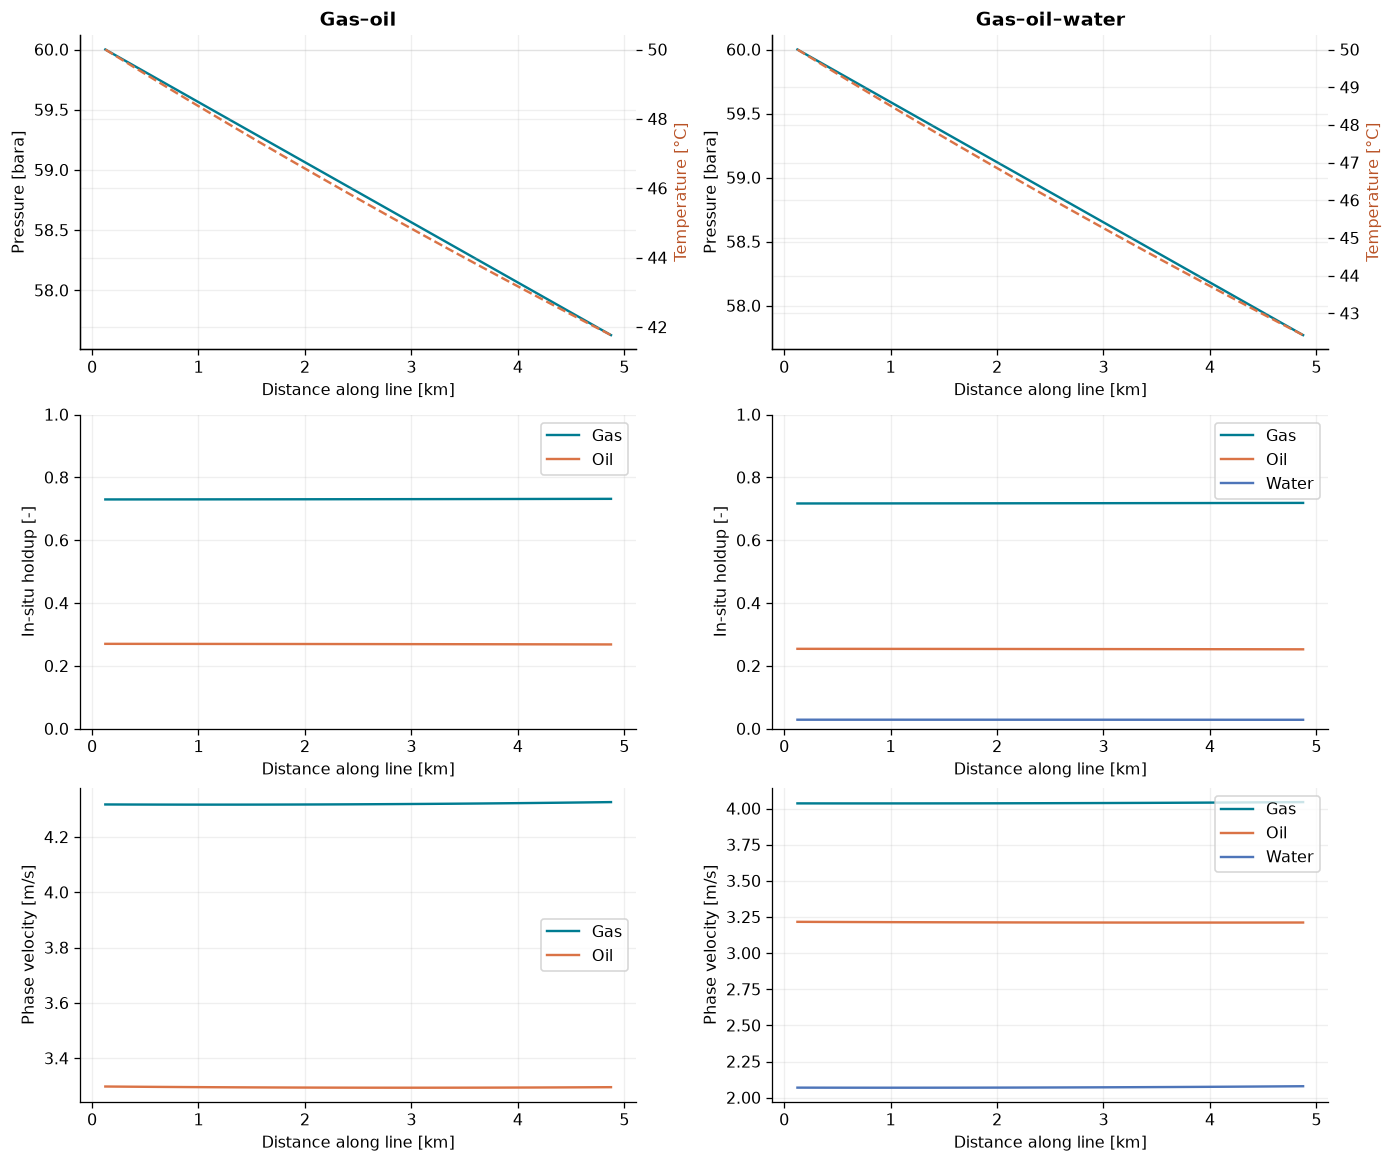

In [5]:
steady_rows = []
for case, pipe in steady_pipes.items():
    data = steady_profiles[case]
    flux_sum = data[["Gas flow [kg/s]", "Oil flow [kg/s]", "Water flow [kg/s]"]].sum(axis=1)
    maximum_flux_error = float(np.max(np.abs(flux_sum / 50.0 - 1.0)))
    holdup_sum = data[["Gas holdup [-]", "Oil holdup [-]", "Water holdup [-]"]].sum(axis=1)
    check(
        f"{case}: section throughput", maximum_flux_error < 1e-8, maximum_flux_error, "< 1e-8"
    )
    check(
        f"{case}: phase volumes",
        np.max(np.abs(holdup_sum - 1.0)) < 1e-12,
        float(np.max(np.abs(holdup_sum - 1.0))),
        "< 1e-12",
    )
    steady_rows.append(
        {
            "Case": case,
            "Arrival [bara]": data["Pressure [bara]"].iloc[-1],
            "Arrival [°C]": data["Temperature [°C]"].iloc[-1],
            "Mean liquid holdup [-]": pipe.getAverageLiquidHoldup(),
            "Liquid inventory [m³]": pipe.getLiquidInventory("m3"),
            "Total inventory [kg]": pipe.getTotalMassInventory(),
            "Dominant regime": str(pipe.getDominantFlowRegime()),
        }
    )
steady_summary = pd.DataFrame(steady_rows)
display(steady_summary.round(4))

fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
for column, (case, data) in enumerate(steady_profiles.items()):
    distance = data["Distance [m]"] / 1000.0
    axes[0, column].plot(distance, data["Pressure [bara]"], label="Pressure")
    temperature_axis = axes[0, column].twinx()
    temperature_axis.plot(distance, data["Temperature [°C]"], color="#DA7346", ls="--")
    temperature_axis.set_ylabel("Temperature [°C]", color="#B95327")
    axes[0, column].set_ylabel("Pressure [bara]")
    axes[0, column].set_title(case)
    for phase in ("Gas", "Oil", "Water"):
        if phase == "Water" and case == "Gas–oil":
            continue
        axes[1, column].plot(distance, data[f"{phase} holdup [-]"], label=phase)
        axes[2, column].plot(distance, data[f"{phase} velocity [m/s]"], label=phase)
    axes[1, column].set_ylabel("In-situ holdup [-]")
    axes[1, column].set_ylim(0, 1)
    axes[1, column].legend()
    axes[2, column].set_ylabel("Phase velocity [m/s]")
    axes[2, column].legend()
    for row in range(3):
        axes[row, column].set_xlabel("Distance along line [km]")
show_figure(fig, "01_steady_profiles.png")

Pressure decreases through friction and the wellstream cools toward the external temperature.
Gas and liquid travel at different speeds, so the retained liquid volume is not the inlet flash
volume-flow fraction. The wet case adds an oil–water split and a third velocity. Compare the
numbers in the summary before drawing conclusions about water production, because total mixture
rate is held fixed. Inspect local extrema, not only averages, before choosing a downstream separator
or investigating a low-point inventory.

## 5. Uphill three-phase flow and mesh refinement

This separate public regression fixture transports 8 kg/s through a 3 km, 0.15 m line rising at
10°. It uses its own composition, 30 bara inlet and 20 °C. It is intentionally different from the
50 kg/s horizontal case. The legacy N-point elevation convention below reproduces the maintained
regression; the newer N+1 cell-face terrain API is demonstrated in the unsplit section.

Compare 30 and 60 cells without changing closure parameters. A small mesh difference supplies
numerical evidence for this case, not general experimental accuracy.

,Cells,Arrival [bara],Mean liquid holdup [-],Mean oil−water slip [m/s]
0,30,7.469114,0.274301,0.449876
1,60,7.429146,0.271630,0.459611


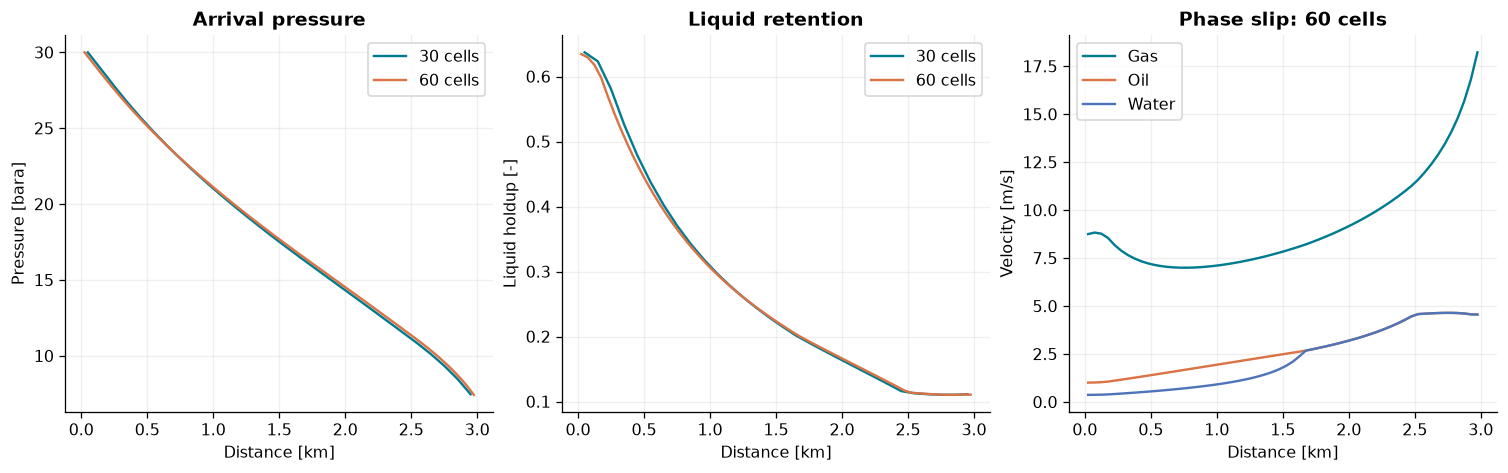

In [6]:
def make_uphill_pipe(sections):
    fluid = Fluid(293.15, 30.0)
    composition = {
        "methane": 0.40,
        "ethane": 0.05,
        "propane": 0.03,
        "n-pentane": 0.15,
        "n-heptane": 0.17,
        "water": 0.20,
    }
    for component, fraction in composition.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    inlet = Stream("uphill wellstream", fluid)
    inlet.setFlowRate(8.0, "kg/sec")
    inlet.run()
    pipe = TwoFluidPipe("three-phase uphill", inlet)
    pipe.setLength(3000.0)
    pipe.setDiameter(0.15)
    pipe.setRoughness(4.5e-5)
    pipe.setNumberOfSections(sections)
    total_rise = 3000.0 * np.sin(np.deg2rad(10.0))
    pipe.setElevationProfile(np.linspace(0.0, total_rise, sections))
    pipe.setEnableWaterOilSlip(True)
    pipe.setSteadyStateMaxWallClockTime(120.0)
    pipe.run()
    steady_evidence(pipe, f"Uphill {sections} cells")
    return pipe


uphill = {count: make_uphill_pipe(count) for count in (30, 60)}
uphill_data = {count: profiles(pipe) for count, pipe in uphill.items()}
uphill_summary = pd.DataFrame(
    [
        {
            "Cells": count,
            "Arrival [bara]": data["Pressure [bara]"].iloc[-1],
            "Mean liquid holdup [-]": 1.0 - data["Gas holdup [-]"].mean(),
            "Mean oil−water slip [m/s]": (
                data["Oil velocity [m/s]"] - data["Water velocity [m/s]"]
            ).mean(),
        }
        for count, data in uphill_data.items()
    ]
)
display(uphill_summary.round(6))
for quantity in ["Arrival [bara]", "Mean liquid holdup [-]"]:
    coarse, fine = uphill_summary[quantity]
    difference = abs(coarse - fine) / abs(fine)
    check(f"Uphill refinement: {quantity}", difference < 0.02, difference, "< 2%")
for count, data in uphill_data.items():
    flux = data[["Gas flow [kg/s]", "Oil flow [kg/s]", "Water flow [kg/s]"]].sum(axis=1)
    check(
        f"Uphill {count}: mass",
        np.max(np.abs(flux - 8.0)) < 8e-8,
        float(np.max(np.abs(flux - 8.0))),
        "< 8e-8 kg/s",
    )
    check(
        f"Uphill {count}: liquids present",
        bool((data[["Oil holdup [-]", "Water holdup [-]"]] > 0).all().all()),
        float(data["Water holdup [-]"].min()),
        "oil and water > 0",
    )

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for count, data in uphill_data.items():
    distance = data["Distance [m]"] / 1000.0
    axes[0].plot(distance, data["Pressure [bara]"], label=f"{count} cells")
    axes[1].plot(distance, 1.0 - data["Gas holdup [-]"], label=f"{count} cells")
for phase in ("Gas", "Oil", "Water"):
    data = uphill_data[60]
    axes[2].plot(data["Distance [m]"] / 1000.0, data[f"{phase} velocity [m/s]"], label=phase)
for axis, title, ylabel in zip(
    axes,
    ["Arrival pressure", "Liquid retention", "Phase slip: 60 cells"],
    ["Pressure [bara]", "Liquid holdup [-]", "Velocity [m/s]"],
):
    axis.set(title=title, xlabel="Distance [km]", ylabel=ylabel)
    axis.legend()
show_figure(fig, "02_uphill_refinement.png")

The uphill pressure gradient includes gravity as well as friction. Oil–water velocity differences
alter the in-situ liquid split while the phase-summed throughput remains 8 kg/s. The inlet section
may differ visibly from interior slip conditions; retaining that point makes the boundary convention
visible. Use the full convergence checks and the displayed 30/60-cell differences together.

## 6. Nearby-rate screen: separate steady solutions

Each point below is a fresh full NeqSim solve at the same inlet pressure and temperature. These
are possible steady operating points; the sweep has no time axis and carries no inventory memory.
It helps distinguish production sensitivity from the subsequent dynamic response.

,Case,Rate [kg/s],Arrival [bara],Liquid inventory [m³],Mean liquid holdup [-]
0,Gas–oil,45.0,58.0811,95.7941,0.2710
1,Gas–oil,50.0,57.6278,95.2009,0.2694
2,Gas–oil,55.0,57.1235,94.6057,0.2677
3,Gas–oil–water,45.0,58.1939,99.8722,0.2826
4,Gas–oil–water,50.0,57.7701,99.7493,0.2822
5,Gas–oil–water,55.0,57.2981,99.7162,0.2821


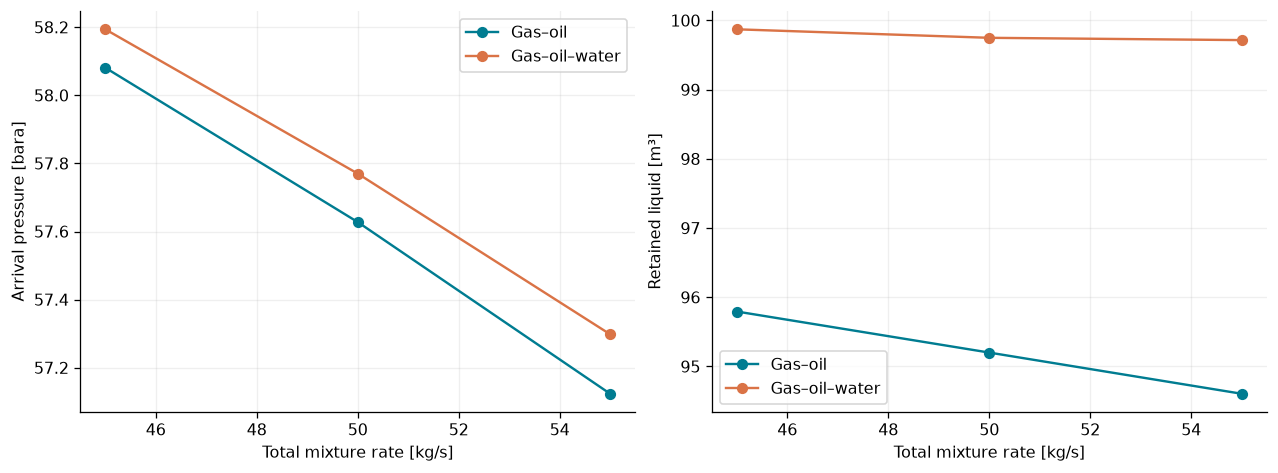

In [7]:
rate_rows = []
for case, with_water in [("Gas–oil", False), ("Gas–oil–water", True)]:
    for rate in (45.0, 50.0, 55.0):
        pipe = make_flowline(with_water, rate)
        steady_evidence(pipe, f"{case}, {rate:g} kg/s")
        rate_rows.append(
            {
                "Case": case,
                "Rate [kg/s]": rate,
                "Arrival [bara]": pipe.getPressureProfile()[-1] / 1e5,
                "Liquid inventory [m³]": pipe.getLiquidInventory("m3"),
                "Mean liquid holdup [-]": pipe.getAverageLiquidHoldup(),
            }
        )
rate_screen = pd.DataFrame(rate_rows)
display(rate_screen.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for case, data in rate_screen.groupby("Case", sort=False):
    axes[0].plot(data["Rate [kg/s]"], data["Arrival [bara]"], "o-", label=case)
    axes[1].plot(data["Rate [kg/s]"], data["Liquid inventory [m³]"], "o-", label=case)
axes[0].set(xlabel="Total mixture rate [kg/s]", ylabel="Arrival pressure [bara]")
axes[1].set(xlabel="Total mixture rate [kg/s]", ylabel="Retained liquid [m³]")
for axis in axes:
    axis.legend()
show_figure(fig, "03_rate_screen.png")

Pressure-loss and retention sensitivities can move differently because holdup and slip change
with rate. The three points are a local engineering screen. They do not identify a minimum stable
production rate or a severe-slugging boundary. The transient calculation below retains a fixed
arrival-pressure boundary, so its eventual upstream pressure is not constrained to 60 bara.

## 7. Dynamic rate cycle with phase-resolved mass accounting

Initialize once at 50 kg/s, then run four intervals: 0–30 s at 50, 30–60 s at 55,
60–90 s at 45, and 90–120 s back at 50 kg/s. Every outer step ends exactly on the event grid.
The solver may take many smaller CFL-controlled internal steps. Re-running `pipe.run()` inside
this loop would erase the evolving state and invalidate the demonstration.

For every accepted interval, use the solver's integrated face transfers:

$$R_k=M_k^{n+1}-M_k^n-M_{k,\mathrm{in}}+M_{k,\mathrm{out}}-M_{k,\mathrm{source}}$$

All terms here are kg. The connected outlet carries the **interval-average** accepted outlet
flow, $M_{\mathrm{out}}/\Delta t$. An inlet–outlet rate mismatch is therefore expected during
inventory accumulation. Sampling endpoint rates and multiplying by the outer step is not an
equivalent conservation check.

The main demonstration uses the legacy integrator with explicit shared-force and coupled-pressure
options. Complete-interval transactions are shown separately below. Every run checks mass,
requested elapsed time, positivity, pressure-limit counts, rejected coupled substeps and outlet clamping.

In [8]:
def requested_rate(time_s, event=True):
    if not event:
        return 50.0
    if time_s < 30.0:
        return 50.0
    if time_s < 60.0:
        return 55.0
    if time_s < 90.0:
        return 45.0
    return 50.0


def dynamic_state(pipe, time_s, inlet_rate):
    data = profiles(pipe)
    return {
        "Time [s]": time_s,
        "Inlet [kg/s]": inlet_rate,
        "Outlet [kg/s]": pipe.getOutletStream().getFlowRate("kg/sec"),
        "Inlet cell [bara]": data["Pressure [bara]"].iloc[0],
        "Outlet cell [bara]": data["Pressure [bara]"].iloc[-1],
        "Mass inventory [kg]": pipe.getTotalMassInventory(),
        "Liquid inventory [m³]": pipe.getLiquidInventory("m3"),
        "Mean liquid holdup [-]": pipe.getAverageLiquidHoldup(),
        "Arrival [°C]": data["Temperature [°C]"].iloc[-1],
    }


def run_rate_cycle(with_water, sections=20, outer_step=1.0, event=True, duration=120.0):
    pipe = make_flowline(with_water, sections=sections)
    label = f"{'wet' if with_water else 'dry'} N={sections}, dt={outer_step}, event={event}"
    steady_evidence(pipe, label)
    pipe.setOutletPressure(float(pipe.getPressureProfile()[-1]), "Pa")
    initial_mass = pipe.getTotalMassInventory()
    history = [dynamic_state(pipe, 0.0, 50.0)]
    ledger = []
    snapshots = {0.0: profiles(pipe)}
    field_history = [profiles(pipe)]
    cumulative_net = 0.0
    n_steps = int(round(duration / outer_step))
    for step in range(n_steps):
        start = step * outer_step
        rate = requested_rate(start, event)
        inlet = pipe.getInletStream()
        if abs(inlet.getFlowRate("kg/sec") - rate) > 1e-10:
            inlet.setFlowRate(rate, "kg/sec")
            inlet.run()
        pipe.runTransient(outer_step, UUID.randomUUID())
        report = pipe.getLastMassBalanceReport()
        elapsed = report.getElapsedTimeSeconds()
        assert abs(elapsed - outer_step) < 1e-9
        now = (step + 1) * outer_step
        for phase_name, phase in {**PHASES, "total": MassPhase.TOTAL}.items():
            ledger.append(
                {
                    "Time [s]": now,
                    "Phase": phase_name,
                    "Initial [kg]": report.getInitialMassKg(phase),
                    "Final [kg]": report.getFinalMassKg(phase),
                    "In [kg]": report.getInletMassKg(phase),
                    "Out [kg]": report.getOutletMassKg(phase),
                    "Source [kg]": report.getSourceMassKg(phase),
                    "Residual [kg]": report.getResidualKg(phase),
                    "Relative residual [-]": report.getRelativeResidual(phase),
                    "Accepted substeps": report.getAcceptedSubsteps(),
                }
            )
        net = report.getInletMassKg(MassPhase.TOTAL) - report.getOutletMassKg(MassPhase.TOTAL)
        net += report.getSourceMassKg(MassPhase.TOTAL)
        cumulative_net += net
        row = dynamic_state(pipe, now, rate)
        row["Integrated net inflow [kg]"] = cumulative_net
        row["Inventory change [kg]"] = row["Mass inventory [kg]"] - initial_mass
        row["Global residual [kg]"] = row["Inventory change [kg]"] - cumulative_net
        history.append(row)
        state = profiles(pipe)
        field_history.append(state)
        numeric = state.select_dtypes(include="number").to_numpy()
        assert np.isfinite(numeric).all()
        holdup = state[["Gas holdup [-]", "Oil holdup [-]", "Water holdup [-]"]].to_numpy()
        assert np.min(holdup) >= -1e-12 and np.max(holdup) <= 1.0 + 1e-12
        assert state["Pressure [bara]"].min() > 1.0
        assert (
            abs(row["Outlet [kg/s]"] - report.getOutletMassKg(MassPhase.TOTAL) / elapsed) < 1e-8
        )
        if any(abs(now - mark) < 1e-9 for mark in (30.0, 60.0, 90.0, 120.0)):
            snapshots[now] = state
    history = pd.DataFrame(history).fillna(0.0)
    ledger = pd.DataFrame(ledger)
    diagnostics = {
        "Case": label,
        "Elapsed [s]": pipe.getSimulationTime(),
        "Maximum phase residual [-]": ledger["Relative residual [-]"].max(),
        "Maximum global residual [kg]": history["Global residual [kg]"].abs().max(),
        "Pressure-limit count": pipe.getTransientPressureLimitCount(),
        "Coupled failure": pipe.isTransientCoupledPressureMomentumFailureDetected(),
        "Pressure correction limited": pipe.isTransientCoupledPressureMomentumCorrectionLimited(),
        "Rejected coupled substeps": pipe.getTransientCoupledPressureMomentumRejectedSubsteps(),
        "Outlet backflow clamped": pipe.isTransientOutletBackflowClamped(),
    }
    check(
        f"{label}: elapsed",
        abs(pipe.getSimulationTime() - duration) < 1e-8,
        pipe.getSimulationTime(),
        duration,
    )
    check(
        f"{label}: phase ledger",
        diagnostics["Maximum phase residual [-]"] < 1e-10,
        diagnostics["Maximum phase residual [-]"],
        "< 1e-10",
    )
    check(
        f"{label}: global mass",
        diagnostics["Maximum global residual [kg]"] < 1e-6,
        diagnostics["Maximum global residual [kg]"],
        "< 1e-6 kg",
    )
    flags = list(diagnostics.values())[4:]
    check(f"{label}: diagnostic flags", not any(flags), str(flags), "all zero/false")
    return {
        "pipe": pipe,
        "history": history,
        "ledger": ledger,
        "snapshots": snapshots,
        "fields": field_history,
        "diagnostics": diagnostics,
    }


dynamic = {
    "Gas–oil": run_rate_cycle(False),
    "Gas–oil–water": run_rate_cycle(True),
}
display(pd.DataFrame([run["diagnostics"] for run in dynamic.values()]).T)
event_rows = []
for case, run in dynamic.items():
    sample = run["history"].loc[run["history"]["Time [s]"].isin([0, 30, 60, 90, 120])].copy()
    sample.insert(0, "Case", case)
    event_rows.append(sample)
event_summary = pd.concat(event_rows)
display(
    event_summary[
        [
            "Case",
            "Time [s]",
            "Inlet [kg/s]",
            "Outlet [kg/s]",
            "Mass inventory [kg]",
            "Liquid inventory [m³]",
            "Arrival [°C]",
        ]
    ].round(5)
)
display(
    event_summary[
        [
            "Case",
            "Time [s]",
            "Inlet cell [bara]",
            "Outlet cell [bara]",
            "Inventory change [kg]",
            "Integrated net inflow [kg]",
            "Global residual [kg]",
        ]
    ].round(8)
)

,0,1
Case,"dry N=20, dt=1.0, event=True","wet N=20, dt=1.0, event=True"
Elapsed [s],120.0,120.0
Maximum phase residual [-],0.0,0.0
Maximum global residual [kg],0.0,0.0
Pressure-limit count,0,0
Coupled failure,False,False
Pressure correction limited,False,False
Rejected coupled substeps,0,0
Outlet backflow clamped,False,False


,Case,Time [s],Inlet [kg/s],Outlet [kg/s],Mass inventory [kg],Liquid inventory [m³],Arrival [°C]
0,Gas–oil,0.0,50.0,50.00000,72409.79940,95.20086,41.76637
30,Gas–oil,30.0,50.0,50.73918,72402.22825,95.19890,41.89990
60,Gas–oil,60.0,55.0,53.61761,72503.56388,95.35389,42.03985
90,Gas–oil,90.0,45.0,50.89911,72244.91007,94.99717,42.18769
120,Gas–oil,120.0,50.0,50.05277,72260.21103,95.03005,42.32946
0,Gas–oil–water,0.0,50.0,50.00000,78530.49055,99.74930,42.42043
30,Gas–oil–water,30.0,50.0,50.72498,78522.85073,99.77462,42.53389
60,Gas–oil–water,60.0,55.0,53.79251,78622.07186,99.99263,42.65265
90,Gas–oil–water,90.0,45.0,51.38390,78352.12352,99.71689,42.77867
120,Gas–oil–water,120.0,50.0,50.42375,78355.59469,99.81829,42.90002


,Case,Time [s],Inlet cell [bara],Outlet cell [bara],Inventory change [kg],Integrated net inflow [kg],Global residual [kg]
0,Gas–oil,0.0,60.000000,57.627795,0.000000,0.000000,0.0
30,Gas–oil,30.0,60.112798,57.627795,-7.571153,-7.571153,0.0
60,Gas–oil,60.0,60.509065,57.627795,93.764473,93.764473,0.0
90,Gas–oil,90.0,59.897833,57.627795,-164.889336,-164.889336,0.0
120,Gas–oil,120.0,60.090415,57.627795,-149.588377,-149.588377,0.0
0,Gas–oil–water,0.0,60.000000,57.770117,0.000000,0.000000,0.0
30,Gas–oil–water,30.0,60.120370,57.770117,-7.639821,-7.639821,0.0
60,Gas–oil–water,60.0,60.515386,57.770117,91.581311,91.581311,-0.0
90,Gas–oil–water,90.0,59.940157,57.770117,-178.367031,-178.367031,0.0
120,Gas–oil–water,120.0,60.125084,57.770117,-174.895866,-174.895866,0.0


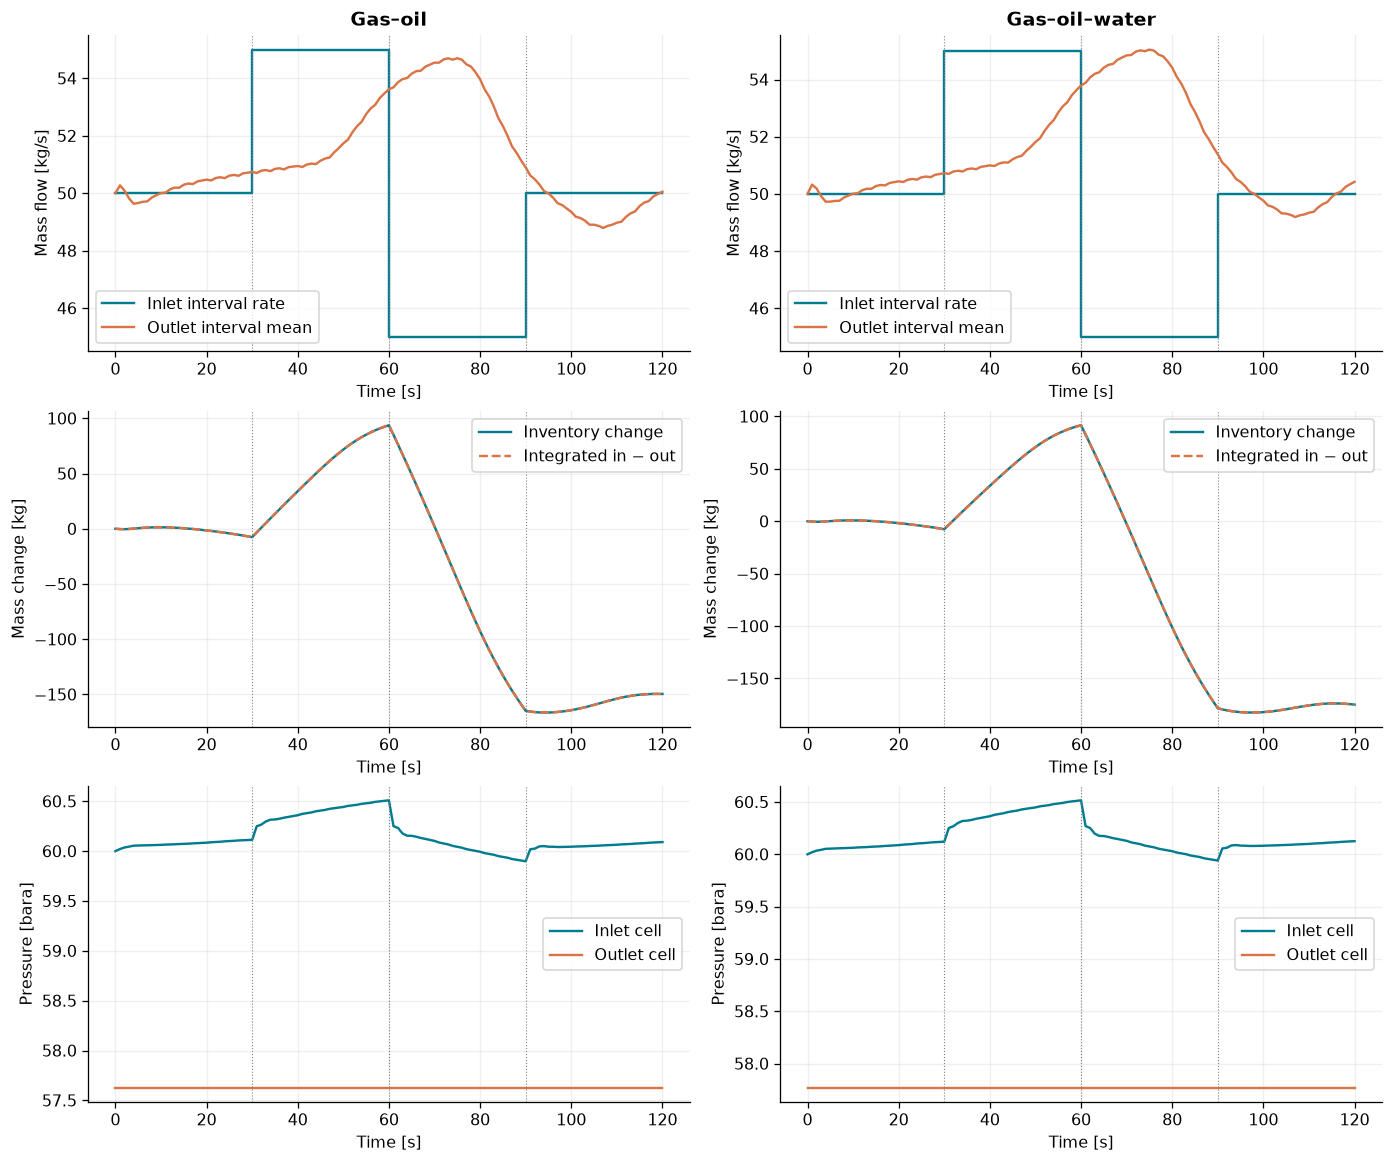

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
for column, (case, run) in enumerate(dynamic.items()):
    data = run["history"]
    times = data["Time [s]"]
    axes[0, column].step(times, data["Inlet [kg/s]"], where="pre", label="Inlet interval rate")
    axes[0, column].plot(times, data["Outlet [kg/s]"], label="Outlet interval mean")
    axes[0, column].set(title=case, ylabel="Mass flow [kg/s]")
    axes[0, column].legend()
    axes[1, column].plot(times, data["Inventory change [kg]"], label="Inventory change")
    axes[1, column].plot(
        times, data["Integrated net inflow [kg]"], "--", label="Integrated in − out"
    )
    axes[1, column].set_ylabel("Mass change [kg]")
    axes[1, column].legend()
    axes[2, column].plot(times, data["Inlet cell [bara]"], label="Inlet cell")
    axes[2, column].plot(times, data["Outlet cell [bara]"], label="Outlet cell")
    axes[2, column].set_ylabel("Pressure [bara]")
    axes[2, column].legend()
    for axis in axes[:, column]:
        for event_time in (30, 60, 90):
            axis.axvline(event_time, color="0.5", lw=0.7, ls=":")
        axis.set_xlabel("Time [s]")
show_figure(fig, "04_dynamic_rate_cycle.png")

The rate disturbance reaches the outlet through the distributed state. During the rate increase,
some additional feed accumulates in the line; after turndown the outlet can temporarily exceed
the inlet. The two mass-change curves overlap because they use independently exposed inventory
and integrated boundary transfers. This is a conservation identity, not an experimental benchmark.
The 120 s record shows early response and recovery, not complete settling over the liquid residence time.

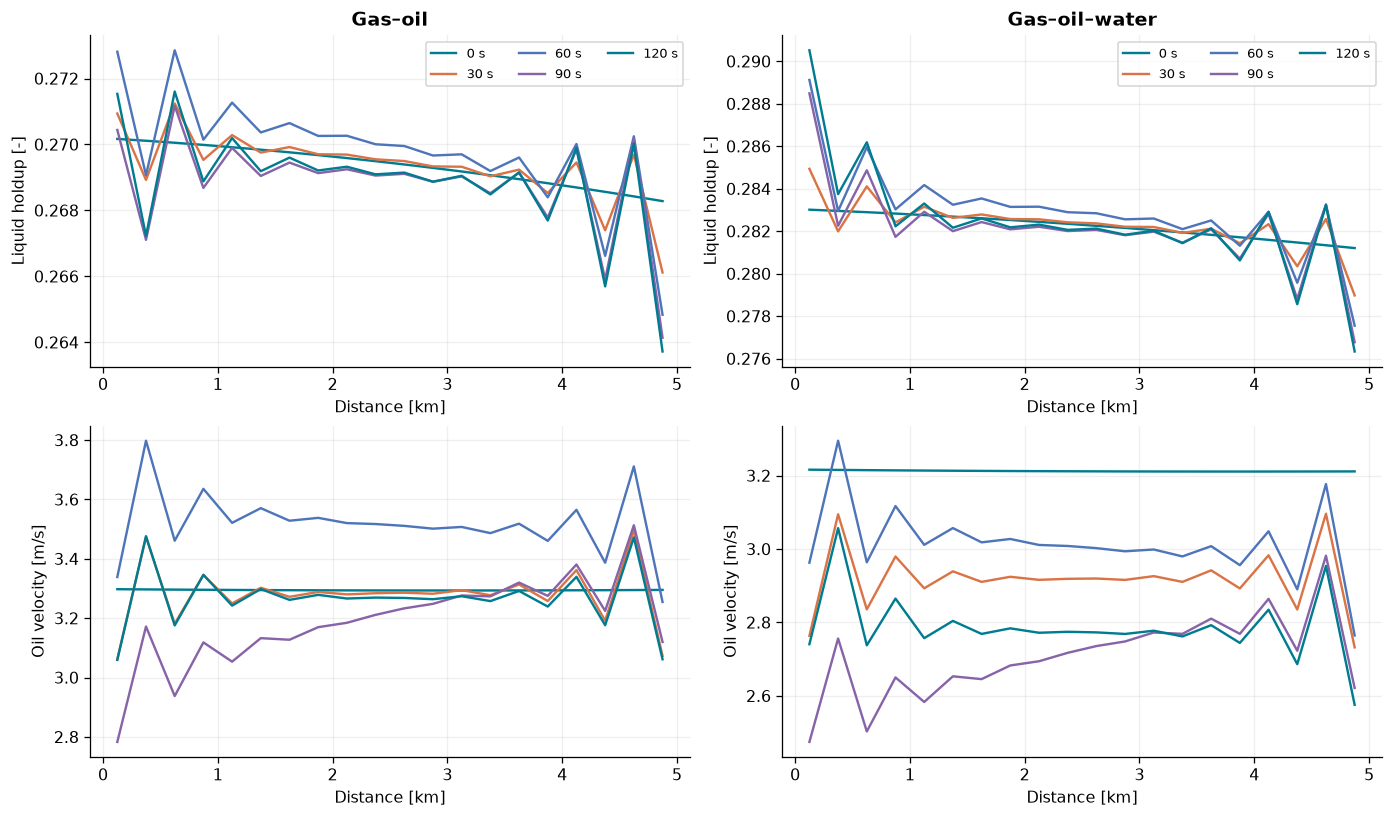

,integrated_in_kg,integrated_out_kg,integrated_source_kg,maximum_relative_residual
Phase,,,,
gas,1071.567546,1076.213156,0.0,6.136452e-16
oil,4435.212130,4096.328637,0.0,5.237175e-16
water,493.220323,1002.354073,0.0,5.546307e-16
total,6000.000000,6174.895866,0.0,4.723142e-16


Phase,gas,oil,water,total
Time [s],1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02
Initial [kg],1.096752e+04,5.795386e+04,9.434640e+03,7.835602e+04
Final [kg],1.096759e+04,5.795854e+04,9.429474e+03,7.835559e+04
In [kg],8.929730e+00,3.696010e+01,4.110169e+00,5.000000e+01
Out [kg],8.859504e+00,3.228740e+01,9.276844e+00,5.042375e+01
Source [kg],0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Residual [kg],-3.096190e-12,-1.456613e-12,-1.967315e-12,-1.197265e-11
Relative residual [-],2.823037e-16,2.513198e-17,2.085204e-16,1.527980e-16
Accepted substeps,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for column, (case, run) in enumerate(dynamic.items()):
    for time_s, state in run["snapshots"].items():
        distance = state["Distance [m]"] / 1000.0
        axes[0, column].plot(distance, 1.0 - state["Gas holdup [-]"], label=f"{time_s:g} s")
        axes[1, column].plot(distance, state["Oil velocity [m/s]"], label=f"{time_s:g} s")
    axes[0, column].set(title=case, ylabel="Liquid holdup [-]", xlabel="Distance [km]")
    axes[1, column].set(ylabel="Oil velocity [m/s]", xlabel="Distance [km]")
    axes[0, column].legend(ncol=3, fontsize=8)
show_figure(fig, "05_dynamic_spatial_memory.png")

wet_ledger = dynamic["Gas–oil–water"]["ledger"]
ledger_summary = wet_ledger.groupby("Phase", sort=False).agg(
    integrated_in_kg=("In [kg]", "sum"),
    integrated_out_kg=("Out [kg]", "sum"),
    integrated_source_kg=("Source [kg]", "sum"),
    maximum_relative_residual=("Relative residual [-]", "max"),
)
display(ledger_summary)
display(wet_ledger.loc[wet_ledger["Time [s]"] == 120.0].set_index("Phase").T)

The snapshots show why an outlet-only trend can hide local inventory redistribution. In the wet
case, gas, oil and water each have a retained mass and a face-transfer history. Phase transfer is
disabled here, so source totals should remain zero. Do not infer component conservation from these
phase ledgers when changing the feed composition; that requires the named-component transport API.

## 8. Separate initialization drift from event response

An initialized steady solution is not automatically an exact fixed point of the transient solver.
Run a wet-line control with unchanged inlet rate over the same 120 s. The control uses the same
geometry, closures, thermal settings and fixed outlet boundary. Its movement is reported rather
than subtracted from the simulation or hidden by discarding a conditioning period.

,Duration [s],Maximum inventory drift [%],Final arrival flow [kg/s],Maximum mass residual [kg]
0,120.0,0.180868,51.774965,4.314415e-11


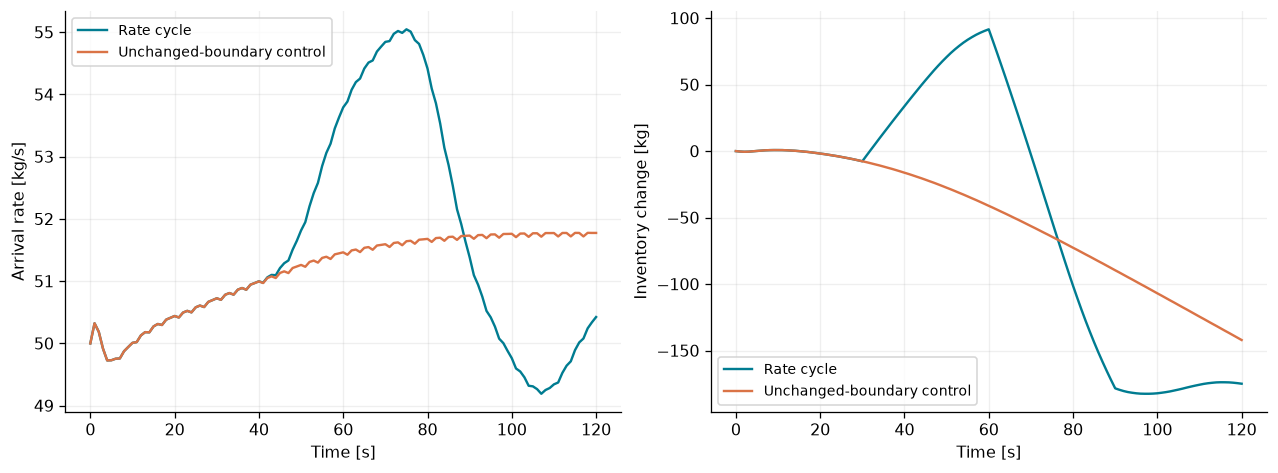

In [11]:
control = run_rate_cycle(True, event=False)
control_history = control["history"]
initial_control_mass = control_history["Mass inventory [kg]"].iloc[0]
control_drift = np.max(
    np.abs(control_history["Mass inventory [kg]"] / initial_control_mass - 1.0)
)
check(
    "Unchanged-boundary 120 s inventory drift",
    control_drift < 0.02,
    float(control_drift),
    "< 2% teaching screen",
)
display(
    pd.DataFrame(
        [
            {
                "Duration [s]": 120.0,
                "Maximum inventory drift [%]": 100.0 * control_drift,
                "Final arrival flow [kg/s]": control_history["Outlet [kg/s]"].iloc[-1],
                "Maximum mass residual [kg]": control_history["Global residual [kg]"]
                .abs()
                .max(),
            }
        ]
    )
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for label, run in [
    ("Rate cycle", dynamic["Gas–oil–water"]),
    ("Unchanged-boundary control", control),
]:
    data = run["history"]
    axes[0].plot(data["Time [s]"], data["Outlet [kg/s]"], label=label)
    axes[1].plot(data["Time [s]"], data["Inventory change [kg]"], label=label)
axes[0].set(xlabel="Time [s]", ylabel="Arrival rate [kg/s]")
axes[1].set(xlabel="Time [s]", ylabel="Inventory change [kg]")
for axis in axes:
    axis.legend(fontsize=9)
show_figure(fig, "06_unchanged_boundary_control.png")

Any control drift is a numerical/model consistency diagnostic. The 2% threshold above is a
declared teaching screen for this 120 s case; it is not a field tolerance or a new qualification of
the default solver. The repository maintains a separate 1,800 s liquid-rich regression for specific
opt-in settings. Conservation can pass while inventory drifts because inlet and outlet transfers
need not remain equal.

## 9. Outer-step and spatial sensitivity

Repeat the wet rate cycle at 20 cells/0.5 s and 40 cells/0.5 s. Compare the 1 s sampling times.
The first comparison changes the outer partition; the second also changes spatial resolution.
The solver still applies internal CFL substeps, so outer-step refinement is not simply halving
every internal integration step. We report differences in arrival flow, inlet-cell pressure,
retained inventory and inventory change rather than assuming a formal convergence order.

,0,1
Comparison,Outer partition: 1 → 0.5 s,Spatial mesh: 20 → 40 cells
Max arrival difference [kg/s],0.148705,0.49044
Max inlet-pressure difference [bar],0.015221,0.135298
Final inventory difference [%],0.00239,0.004047
Final inventory-change difference [kg],1.872886,3.828988


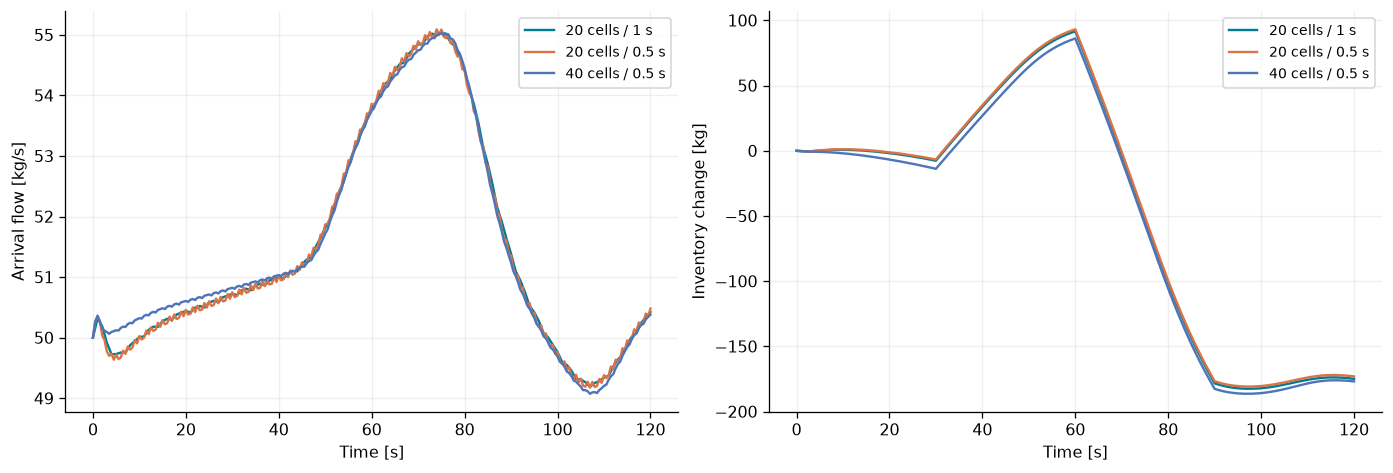

In [12]:
refined_time = run_rate_cycle(True, sections=20, outer_step=0.5)
refined_mesh = run_rate_cycle(True, sections=40, outer_step=0.5)
reference = dynamic["Gas–oil–water"]["history"]
sensitivity_rows = []
for label, coarse_run, fine_run in [
    ("Outer partition: 1 → 0.5 s", dynamic["Gas–oil–water"], refined_time),
    ("Spatial mesh: 20 → 40 cells", refined_time, refined_mesh),
]:
    coarse = coarse_run["history"].set_index("Time [s]")
    fine = fine_run["history"].set_index("Time [s]").loc[coarse.index]
    metrics = {
        "Max arrival difference [kg/s]": float(
            (coarse["Outlet [kg/s]"] - fine["Outlet [kg/s]"]).abs().max()
        ),
        "Max inlet-pressure difference [bar]": float(
            (coarse["Inlet cell [bara]"] - fine["Inlet cell [bara]"]).abs().max()
        ),
        "Final inventory difference [%]": 100.0
        * abs(
            coarse["Mass inventory [kg]"].iloc[-1] / fine["Mass inventory [kg]"].iloc[-1] - 1.0
        ),
        "Final inventory-change difference [kg]": abs(
            coarse["Inventory change [kg]"].iloc[-1] - fine["Inventory change [kg]"].iloc[-1]
        ),
    }
    sensitivity_rows.append({"Comparison": label, **metrics})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(6).T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for label, run in [
    ("20 cells / 1 s", dynamic["Gas–oil–water"]),
    ("20 cells / 0.5 s", refined_time),
    ("40 cells / 0.5 s", refined_mesh),
]:
    data = run["history"]
    axes[0].plot(data["Time [s]"], data["Outlet [kg/s]"], label=label)
    axes[1].plot(data["Time [s]"], data["Inventory change [kg]"], label=label)
axes[0].set(xlabel="Time [s]", ylabel="Arrival flow [kg/s]")
axes[1].set(xlabel="Time [s]", ylabel="Inventory change [kg]")
for axis in axes:
    axis.legend(fontsize=9)
show_figure(fig, "07_dynamic_sensitivity.png")

A fine-grid initialization can contain a different total inventory from a coarse one. That is why
both absolute inventory and change from each grid's own initial inventory are reported. Conservation
and clean diagnostics remain mandatory for every run. The observed sensitivity bounds apply only
to this synthetic, horizontal, modest-rate-change case; add more meshes and a suitable independent
benchmark before selecting a design tolerance.

## 10. See the evolving flow field

The time–distance maps below show changes relative to each line's own initial steady profile.
They reveal where the rate events affect pressure and retained liquid. Colors represent calculated
states; these are not fitted transport speeds or measured slug fronts. The animation combines the
wet-line phase-area fractions, spatial pressure and arriving-flow history. Its static 60 s frame is
stored as a fallback for viewers that do not animate GIF outputs.

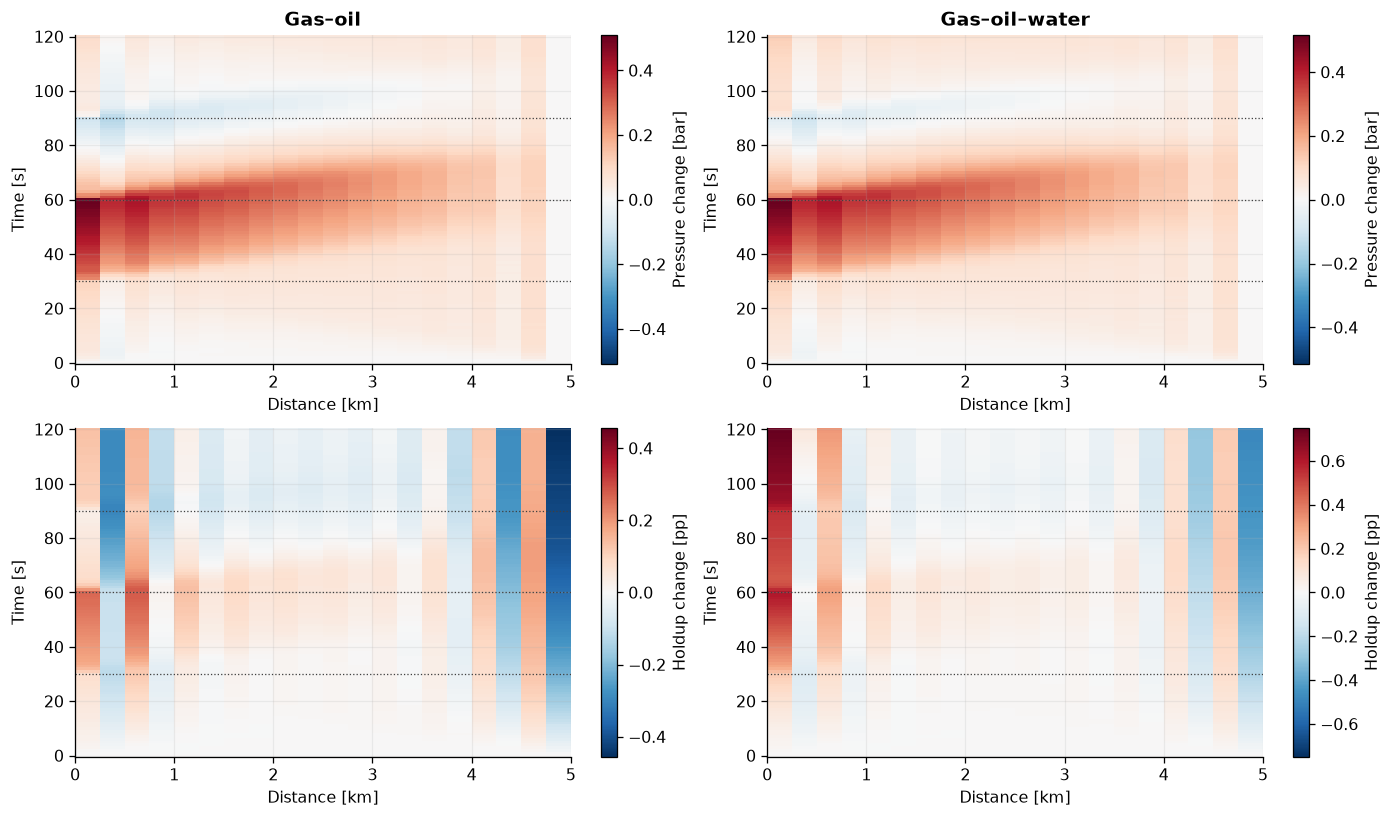


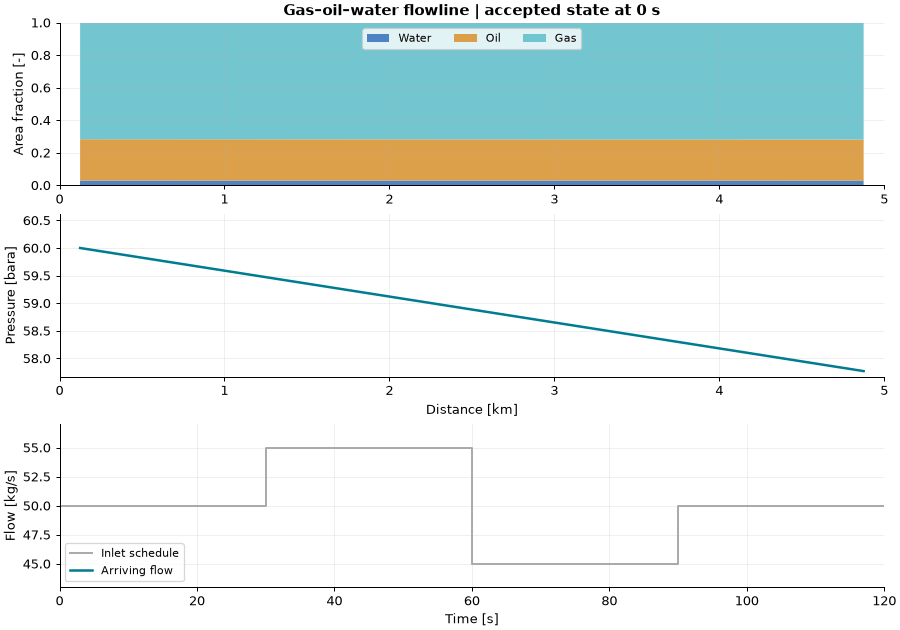

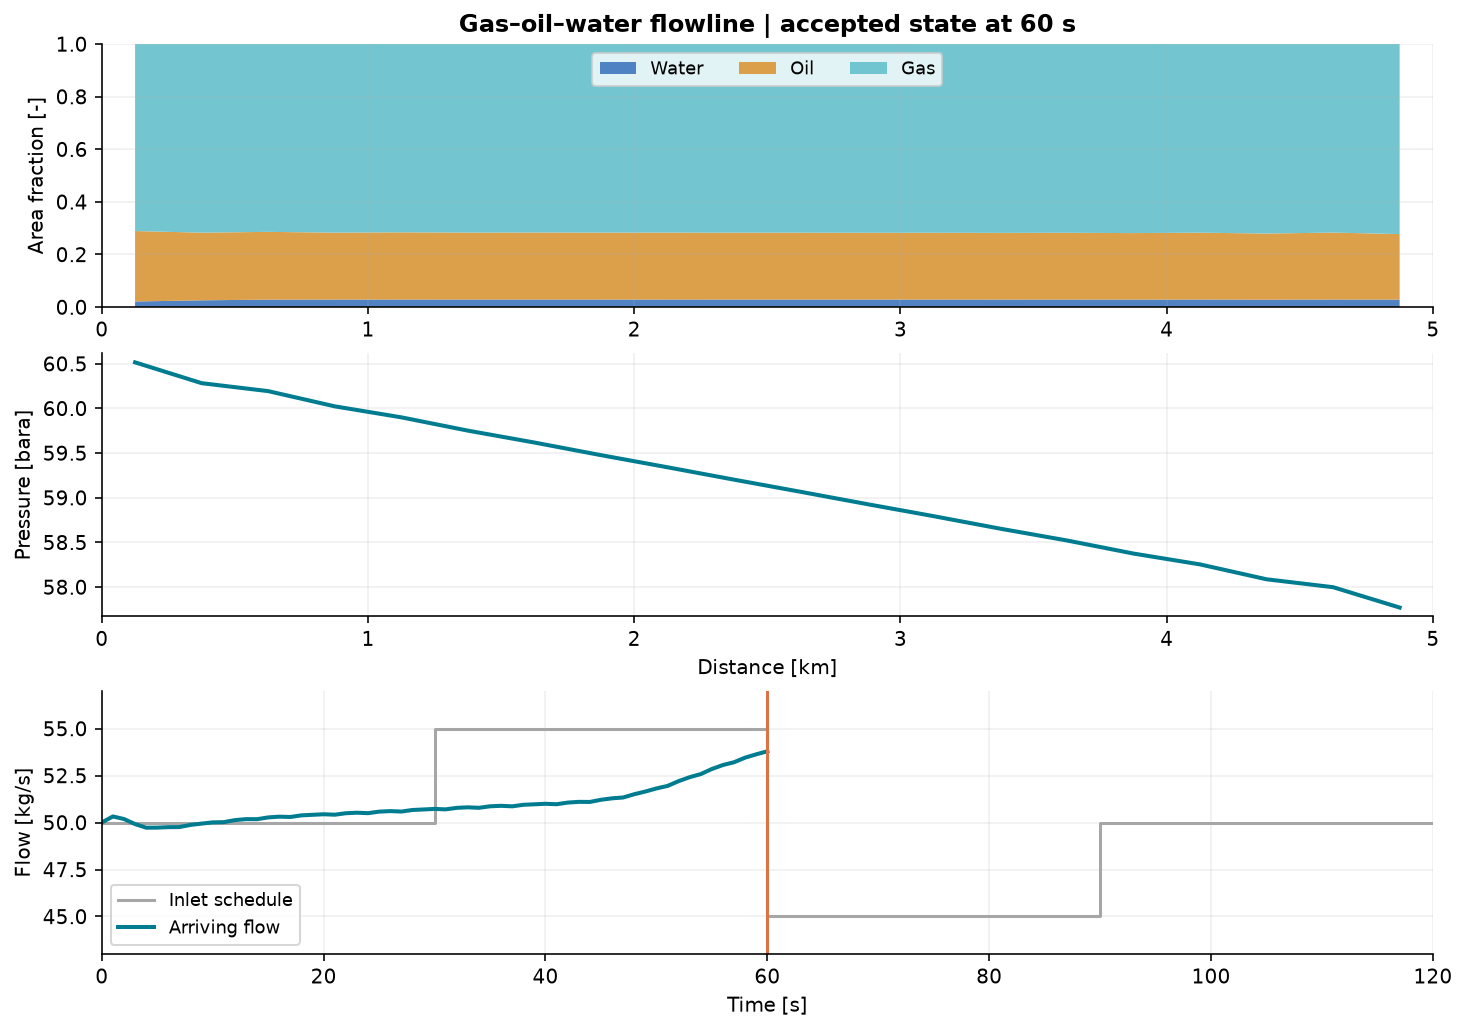

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for column, (case, run) in enumerate(dynamic.items()):
    pressure_field = np.stack([frame["Pressure [bara]"].to_numpy() for frame in run["fields"]])
    liquid_field = np.stack(
        [1.0 - frame["Gas holdup [-]"].to_numpy() for frame in run["fields"]]
    )
    changes = [pressure_field - pressure_field[0], 100.0 * (liquid_field - liquid_field[0])]
    for row, (change, units) in enumerate(
        zip(changes, ["Pressure change [bar]", "Holdup change [pp]"])
    ):
        magnitude = max(float(np.abs(change).max()), 1e-8)
        mesh = axes[row, column].pcolormesh(
            run["fields"][0]["Distance [m]"] / 1000.0,
            run["history"]["Time [s]"],
            change,
            shading="auto",
            cmap="RdBu_r",
            vmin=-magnitude,
            vmax=magnitude,
        )
        fig.colorbar(mesh, ax=axes[row, column], label=units)
        axes[row, column].set(xlabel="Distance [km]", ylabel="Time [s]")
        for event_time in (30, 60, 90):
            axes[row, column].axhline(event_time, color="0.25", ls=":", lw=0.8)
    axes[0, column].set_title(case)
show_figure(fig, "08_time_distance_maps.png")

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, Image
import base64

wet_run = dynamic["Gas–oil–water"]
animation_frames = list(range(0, len(wet_run["fields"]), 4))
fig, animation_axes = plt.subplots(3, 1, figsize=(10, 7), constrained_layout=True)
phase_colors = ["#477CC0", "#DB9A40", "#6BC3CE"]
all_pressures = np.concatenate([frame["Pressure [bara]"] for frame in wet_run["fields"]])
history = wet_run["history"]


def draw_flow_frame(frame_index):
    state = wet_run["fields"][frame_index]
    time_s = float(history["Time [s]"].iloc[frame_index])
    distance = state["Distance [m]"] / 1000.0
    for axis in animation_axes:
        axis.clear()
    animation_axes[0].stackplot(
        distance,
        state["Water holdup [-]"],
        state["Oil holdup [-]"],
        state["Gas holdup [-]"],
        colors=phase_colors,
        labels=["Water", "Oil", "Gas"],
        alpha=0.95,
    )
    animation_axes[0].set(
        ylim=(0, 1),
        xlim=(0, 5),
        ylabel="Area fraction [-]",
        title=f"Gas–oil–water flowline | accepted state at {time_s:.0f} s",
    )
    animation_axes[0].legend(loc="upper center", ncol=3, fontsize=9)
    animation_axes[1].plot(distance, state["Pressure [bara]"], color="#007C91", lw=2)
    animation_axes[1].set(
        xlabel="Distance [km]",
        ylabel="Pressure [bara]",
        xlim=(0, 5),
        ylim=(all_pressures.min() - 0.1, all_pressures.max() + 0.1),
    )
    animation_axes[2].step(
        history["Time [s]"],
        history["Inlet [kg/s]"],
        where="pre",
        color="0.65",
        label="Inlet schedule",
    )
    visible = history.iloc[: frame_index + 1]
    animation_axes[2].plot(
        visible["Time [s]"],
        visible["Outlet [kg/s]"],
        color="#007C91",
        lw=2,
        label="Arriving flow",
    )
    animation_axes[2].axvline(time_s, color="#DA7346", lw=1.5)
    animation_axes[2].set(xlim=(0, 120), ylim=(43, 57), xlabel="Time [s]", ylabel="Flow [kg/s]")
    animation_axes[2].legend(loc="lower left", fontsize=9)


draw_flow_frame(60)
fig.savefig(OUTPUT_DIR / "09_animation_static_60s.png", bbox_inches="tight")
movie = FuncAnimation(fig, draw_flow_frame, frames=animation_frames, interval=160)
movie.save(OUTPUT_DIR / "wellstream_rate_cycle.gif", writer=PillowWriter(fps=6), dpi=90)
plt.close(fig)
animation_b64 = base64.b64encode(
    (OUTPUT_DIR / "wellstream_rate_cycle.gif").read_bytes()
).decode()
display(
    HTML(
        f'<img alt="Calculated wet-flowline rate-cycle animation" '
        f'style="max-width:100%" src="data:image/gif;base64,{animation_b64}">'
    )
)
display(Image(filename=str(OUTPUT_DIR / "09_animation_static_60s.png")))

The upper animation panel plots **cross-sectional area fractions**, not literal layer heights
in a circular cross-section. The gas occupies most of the volume while liquid dominates much of the
mass inventory. Pressure and holdup maps have their own labeled color scales so small spatial
changes remain visible. The displayed dynamics contain a rate disturbance; no synthetic slug
markers or hand-drawn moving particles have been added.

## 11. Hydrate evaluation along the steady and dynamic line

Calculate freshwater hydrate-equilibrium temperatures from the **same wet wellstream composition**
at a pressure grid spanning 20–80 bara. No methanol, MEG or dissolved salts are included. Pressure
interpolation is used only inside this evaluated range and checked against a direct calculation.
The margin is

$$\Delta T_H(x,t)=T_{\mathrm{fluid}}(x,t)-T_{H,\mathrm{eq}}(p(x,t),z)$$

Positive margin means the bulk fluid lies above the calculated equilibrium temperature; negative
margin identifies a thermodynamic hydrate region when free water is available. It does not give
nucleation time, growth rate, blockage probability or an inhibitor dosage.

A deliberately high heat-transfer case, 60 W/(m²·K), is added to expose a cold-end crossing. It is
a **clean-fluid thermal screening path** with the same inlet/geometry; hydrate solids and resulting
hydraulic feedback are not simulated beyond the crossing. The warm rate-cycle case remains a
separate fully checked hydraulic calculation.

Minimum hydrate margin during the warm 120 s rate cycle: 28.041 K


,Case,Minimum hydrate margin [K],First flagged sample [m],Flagged samples
0,Warm line: U = 5,28.0414,none,0
1,Cold screen: U = 60,-4.7195,3625.0,6


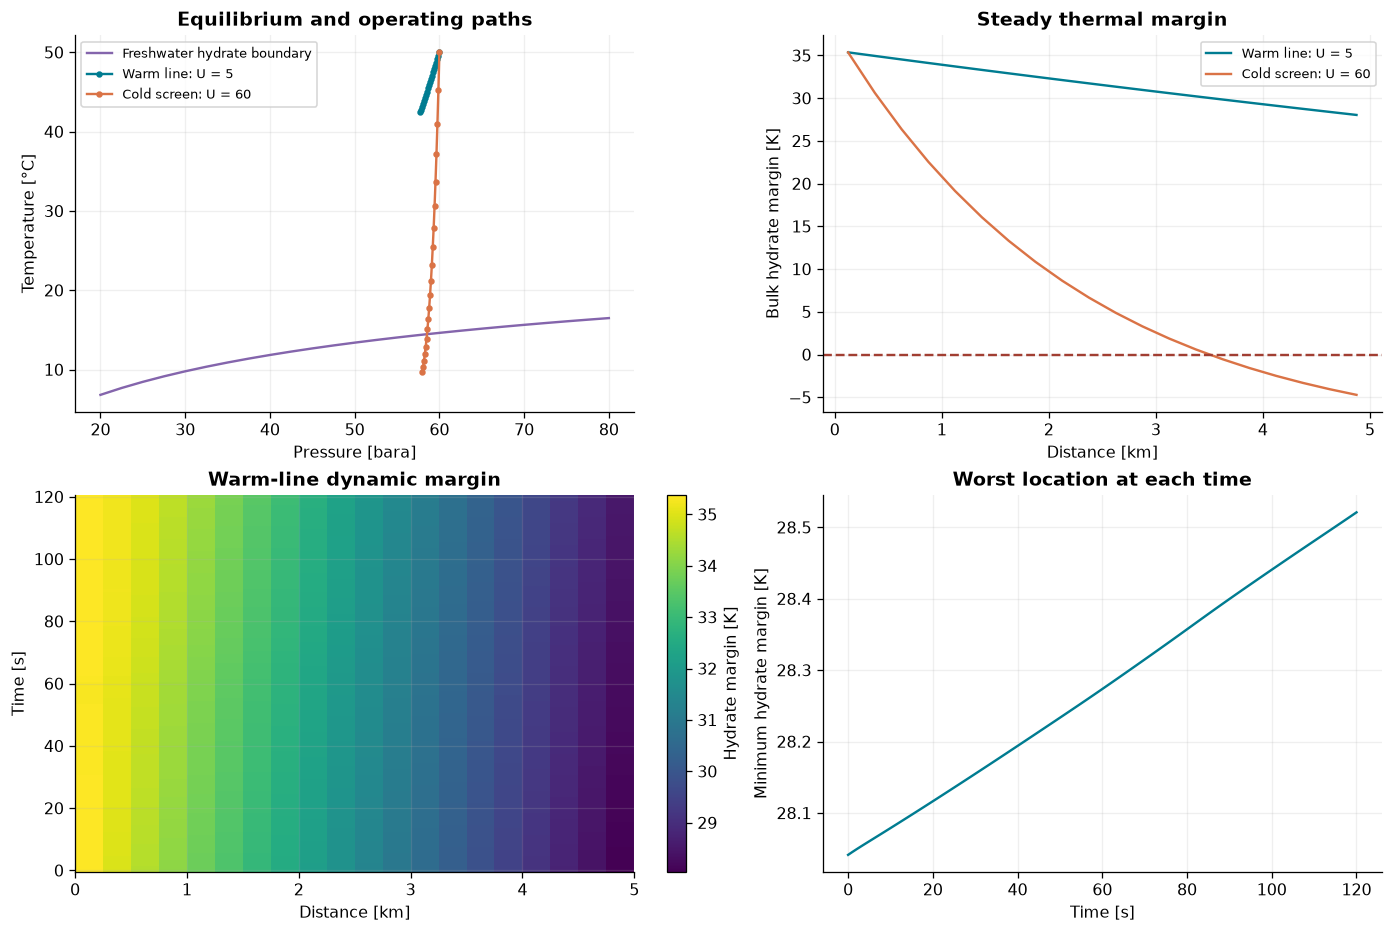

In [14]:
ThermoOps = J("neqsim.thermodynamicoperations.ThermodynamicOperations")


def hydrate_temperature(pressure_bara):
    trial = feeds["Gas–oil–water"].getFluid().clone()
    trial.setPressure(float(pressure_bara))
    trial.setTemperature(283.15)
    trial.setHydrateCheck(True)
    ThermoOps(trial).hydrateFormationTemperature()
    temperature_c = trial.getTemperature() - 273.15
    assert np.isfinite(temperature_c) and -20.0 < temperature_c < 40.0
    return temperature_c


hydrate_pressure_grid = np.linspace(20.0, 80.0, 25)
hydrate_temperature_grid = np.array([hydrate_temperature(p) for p in hydrate_pressure_grid])


def hydrate_limit(pressure_bara):
    pressure = np.asarray(pressure_bara)
    assert pressure.min() >= hydrate_pressure_grid.min()
    assert pressure.max() <= hydrate_pressure_grid.max()
    return np.interp(pressure, hydrate_pressure_grid, hydrate_temperature_grid)


probe_pressure = 58.3
interpolation_error = abs(
    float(hydrate_limit(probe_pressure)) - hydrate_temperature(probe_pressure)
)
check(
    "Hydrate interpolation at 58.3 bara",
    interpolation_error < 0.02,
    interpolation_error,
    "< 0.02 K",
)
check(
    "Freshwater hydrate pressure trend",
    bool((np.diff(hydrate_temperature_grid) > 0).all()),
    float(np.diff(hydrate_temperature_grid).min()),
    "> 0 K per grid interval",
)
cold_pipe = make_flowline(True, solve=False)
cold_pipe.setHeatTransferCoefficient(60.0)
cold_pipe.run()
steady_evidence(cold_pipe, "Cold hydrate screening path")
cold_profile = profiles(cold_pipe)
hydrate_rows = []
hydrate_profiles = {}
for label, data in [
    ("Warm line: U = 5", steady_profiles["Gas–oil–water"]),
    ("Cold screen: U = 60", cold_profile),
]:
    evaluated = data.copy()
    evaluated["Hydrate equilibrium [°C]"] = hydrate_limit(data["Pressure [bara]"])
    evaluated["Hydrate margin [K]"] = (
        data["Temperature [°C]"] - evaluated["Hydrate equilibrium [°C]"]
    )
    exposed = evaluated["Hydrate margin [K]"] < 0.0
    first_cell = float(evaluated.loc[exposed, "Distance [m]"].min()) if exposed.any() else None
    hydrate_rows.append(
        {
            "Case": label,
            "Minimum hydrate margin [K]": evaluated["Hydrate margin [K]"].min(),
            "First flagged sample [m]": first_cell,
            "Flagged samples": int(exposed.sum()),
        }
    )
    hydrate_profiles[label] = evaluated
hydrate_summary = pd.DataFrame(hydrate_rows)
display(hydrate_summary.round(4).fillna("none"))

wet_fields = dynamic["Gas–oil–water"]["fields"]
hydrate_margin_field = np.stack(
    [
        frame["Temperature [°C]"].to_numpy() - hydrate_limit(frame["Pressure [bara]"])
        for frame in wet_fields
    ]
)
print(
    f"Minimum hydrate margin during the warm 120 s rate cycle: {hydrate_margin_field.min():.3f} K"
)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes[0, 0].plot(
    hydrate_pressure_grid,
    hydrate_temperature_grid,
    color="#8465AC",
    label="Freshwater hydrate boundary",
)
for label, data in hydrate_profiles.items():
    axes[0, 0].plot(data["Pressure [bara]"], data["Temperature [°C]"], "o-", ms=3, label=label)
    axes[0, 1].plot(data["Distance [m]"] / 1000.0, data["Hydrate margin [K]"], label=label)
axes[0, 0].set(
    xlabel="Pressure [bara]", ylabel="Temperature [°C]", title="Equilibrium and operating paths"
)
axes[0, 0].legend(fontsize=8)
axes[0, 1].axhline(0, color="#A13E32", ls="--")
axes[0, 1].set(
    xlabel="Distance [km]", ylabel="Bulk hydrate margin [K]", title="Steady thermal margin"
)
axes[0, 1].legend(fontsize=8)
mesh = axes[1, 0].pcolormesh(
    wet_fields[0]["Distance [m]"] / 1000.0,
    dynamic["Gas–oil–water"]["history"]["Time [s]"],
    hydrate_margin_field,
    shading="auto",
    cmap="viridis",
)
fig.colorbar(mesh, ax=axes[1, 0], label="Hydrate margin [K]")
axes[1, 0].set(xlabel="Distance [km]", ylabel="Time [s]", title="Warm-line dynamic margin")
axes[1, 1].plot(
    dynamic["Gas–oil–water"]["history"]["Time [s]"],
    hydrate_margin_field.min(axis=1),
    color="#007C91",
)
axes[1, 1].set(
    xlabel="Time [s]", ylabel="Minimum hydrate margin [K]", title="Worst location at each time"
)
show_figure(fig, "10_hydrate_steady_dynamic.png")
pd.DataFrame(
    {
        "Pressure [bara]": hydrate_pressure_grid,
        "Hydrate equilibrium [°C]": hydrate_temperature_grid,
    }
).to_csv(OUTPUT_DIR / "hydrate_boundary.csv", index=False)
for index, (label, data) in enumerate(hydrate_profiles.items()):
    data.to_csv(OUTPUT_DIR / f"hydrate_profile_{index}.csv", index=False)

The high-U case illustrates how loss of thermal protection can move part of the path into the
hydrate-equilibrium region. The first flagged sample is a grid location, not an exact deposition
position. The dynamic margin map uses calculated bulk temperatures and pressures from the warm
rate cycle; its absolute values and small time variations should be read separately. Wall
temperature, free-water wetting, residence time and kinetics can change a real flow-assurance decision.

## 12. Wax evaluation with an explicit heavy-end assay

The original light-component wellstreams do not contain a characterized waxy heavy tail. For a
meaningful wax demonstration, use a **separate synthetic oil assay** based on the maintained
`WaxFractionSimTest`: methane 6.78 relative moles; C19 TBP 10.13, molecular weight 0.170 kg/mol,
density 0.7814 g/cm³; C20+ 10.62, molecular weight 0.381 kg/mol and density 0.850871882888 g/cm³.
The C20+ distribution is characterized and the default Pedersen wax model generates wax-forming
pseudo-components. These correlations and default wax parameters are not fitted to a real crude.

Every curve point below is a fresh-clone NeqSim TP flash. No monotonicity repair is applied.
An appearance bracket is found for a wax mass fraction above $10^{-8}$ of the total mixture,
with a temperature bracket narrower than 0.05 K. Wax-flash mass closure is checked to 1e-6
relative (one part per million), and the actual worst residual is reported. This is a **TP-flash onset bracket**, not a
validated replacement for the direct WAT solver. The direct solver has an internal inconsistency
tracked in [NeqSim #3709](https://github.com/equinor/neqsim/issues/3709); its output is not used
to declare a safe wax margin.

The waxy fluid has its own 20 kg/s, 80 °C, 60 bara, 5 km / 0.30 m clean-fluid thermal path with
U = 10 W/(m²·K). Wax equilibrium is evaluated on clones. Below onset, the plotted hydraulic path
is an incipient-risk extrapolation: wax deposition, viscosity increase, diameter loss and plugging
are not fed back into the pipe model. Wax mass fraction is **not** deposited wax thickness.

Maximum wax-flash relative mass error: 6.719e-08


,Pressure [bara],Wax-positive lower [°C],Wax-free upper [°C],Bracket width [K]
0,40.0,64.5625,64.59375,0.03125
1,60.0,64.5000,64.53125,0.03125
2,80.0,64.7500,64.78125,0.03125


,Distance [m],Pressure [bara],Temperature [°C],TP wax onset estimate [°C],Wax thermal margin [K],Raw equilibrium wax [mass %]
0,125.0,60.0000,80.0000,64.5156,15.4844,0.0000
1,375.0,59.9900,76.1849,64.5157,11.6693,0.0000
2,625.0,59.9798,72.5614,64.5157,8.0457,0.0000
3,875.0,59.9695,69.1198,64.5157,4.6041,0.0000
4,1125.0,59.9591,65.8510,64.5158,1.3353,0.0000
5,1375.0,59.9486,62.7464,64.5158,-1.7694,1.4494
6,1625.0,59.9380,59.7976,64.5158,-4.7182,3.2520
7,1875.0,59.9273,56.9969,64.5159,-7.5190,4.5221
8,2125.0,59.9165,54.3368,64.5159,-10.1791,5.5289
9,2375.0,59.9050,51.8103,64.5159,-12.7056,6.4263


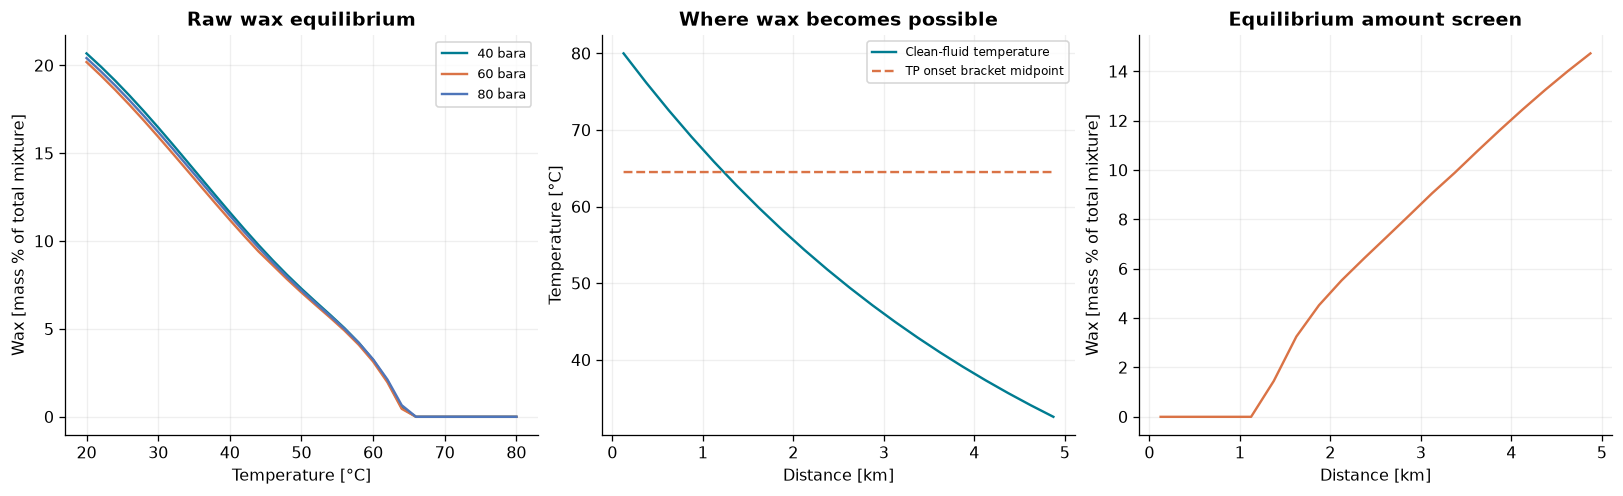

In [15]:
Database = J("neqsim.util.database.NeqSimDataBase")


def make_wax_assay():
    Database.setCreateTemporaryTables(True)
    try:
        fluid = Fluid(298.0, 10.0)
        fluid.addComponent("methane", 6.78)
        fluid.addTBPfraction("C19", 10.13, 0.170, 0.7814)
        fluid.addPlusFraction("C20", 10.62, 0.381, 0.850871882888)
        fluid.setMixingRule("classic")
        fluid.getCharacterization().characterisePlusFraction()
        fluid.getWaxModel().addTBPWax()
        fluid.createDatabase(True)
        fluid.setMixingRule("classic")
        fluid.addSolidComplexPhase("wax")
        fluid.setMultiphaseWaxCheck(True)
        fluid.setMultiPhaseCheck(True)
        fluid.init(0)
        fluid.init(1)
    finally:
        Database.setCreateTemporaryTables(False)
    return fluid


wax_assay = make_wax_assay()
wax_balance_errors = []


def raw_wax_fraction(temperature_c, pressure_bara):
    trial = wax_assay.clone()
    trial.setTemperature(float(temperature_c) + 273.15)
    trial.setPressure(float(pressure_bara))
    ThermoOps(trial).TPflash()
    fraction = trial.getPhaseFraction("wax", "mass") if trial.hasPhaseType("wax") else 0.0
    assert np.isfinite(fraction) and 0.0 <= fraction <= 1.0
    phase_mass = sum(
        trial.getPhase(i).getNumberOfMolesInPhase() * trial.getPhase(i).getMolarMass()
        for i in range(trial.getNumberOfPhases())
    )
    system_mass = trial.getTotalNumberOfMoles() * trial.getMolarMass()
    relative_mass_error = abs(phase_mass / system_mass - 1.0)
    wax_balance_errors.append(relative_mass_error)
    assert relative_mass_error < 1e-6
    return float(fraction)


wax_curve_rows = []
wax_brackets = []
for pressure in (40.0, 60.0, 80.0):
    temperatures = np.arange(80.0, 19.0, -2.0)
    fractions = np.array([raw_wax_fraction(t, pressure) for t in temperatures])
    check(
        f"Wax raw monotonicity at {pressure:g} bara",
        bool((np.diff(fractions) >= -1e-7).all()),
        float(np.diff(fractions).min()),
        ">= -1e-7",
    )
    for temperature, fraction in zip(temperatures, fractions):
        wax_curve_rows.append(
            {
                "Pressure [bara]": pressure,
                "Temperature [°C]": temperature,
                "Wax [mass % of mixture]": 100.0 * fraction,
            }
        )
    first_positive = int(np.flatnonzero(fractions > 1e-8)[0])
    assert first_positive > 0
    lower = float(temperatures[first_positive])
    upper = float(temperatures[first_positive - 1])
    while upper - lower > 0.05:
        midpoint = 0.5 * (lower + upper)
        if raw_wax_fraction(midpoint, pressure) > 1e-8:
            lower = midpoint
        else:
            upper = midpoint
    wax_brackets.append(
        {
            "Pressure [bara]": pressure,
            "Wax-positive lower [°C]": lower,
            "Wax-free upper [°C]": upper,
            "Bracket width [K]": upper - lower,
        }
    )
wax_curves = pd.DataFrame(wax_curve_rows)
wax_onset = pd.DataFrame(wax_brackets)
display(wax_onset)

wax_hydraulic_fluid = wax_assay.clone()
wax_hydraulic_fluid.setMultiphaseWaxCheck(False)
wax_hydraulic_fluid.setTemperature(353.15)
wax_hydraulic_fluid.setPressure(60.0)
wax_feed = Stream("waxy oil screening feed", wax_hydraulic_fluid)
wax_feed.setFlowRate(20.0, "kg/sec")
wax_feed.run()
wax_pipe = TwoFluidPipe("waxy clean-fluid screening path", wax_feed)
wax_pipe.setLength(5000.0)
wax_pipe.setDiameter(0.30)
wax_pipe.setNumberOfSections(20)
wax_pipe.setElevationProfile(np.zeros(20))
wax_pipe.setHeatTransferCoefficient(10.0)
wax_pipe.setSurfaceTemperature(4.0, "C")
wax_pipe.setEnableSlugTracking(False)
wax_pipe.setSteadyStateMaxWallClockTime(120.0)
wax_pipe.run()
steady_evidence(wax_pipe, "Wax clean-fluid screening path")
wax_profile = profiles(wax_pipe)
onset_mid = 0.5 * (wax_onset["Wax-positive lower [°C]"] + wax_onset["Wax-free upper [°C]"])
wax_profile["TP wax onset estimate [°C]"] = np.interp(
    wax_profile["Pressure [bara]"],
    wax_onset["Pressure [bara]"],
    onset_mid,
)
wax_profile["Wax thermal margin [K]"] = (
    wax_profile["Temperature [°C]"] - wax_profile["TP wax onset estimate [°C]"]
)
wax_profile["Raw equilibrium wax [mass %]"] = [
    100.0 * raw_wax_fraction(t, p)
    for t, p in zip(wax_profile["Temperature [°C]"], wax_profile["Pressure [bara]"])
]
display(
    wax_profile[
        [
            "Distance [m]",
            "Pressure [bara]",
            "Temperature [°C]",
            "TP wax onset estimate [°C]",
            "Wax thermal margin [K]",
            "Raw equilibrium wax [mass %]",
        ]
    ].round(4)
)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for pressure, curve in wax_curves.groupby("Pressure [bara]"):
    axes[0].plot(
        curve["Temperature [°C]"], curve["Wax [mass % of mixture]"], label=f"{pressure:g} bara"
    )
axes[0].set(
    xlabel="Temperature [°C]",
    ylabel="Wax [mass % of total mixture]",
    title="Raw wax equilibrium",
)
axes[0].legend(fontsize=8)
distance = wax_profile["Distance [m]"] / 1000.0
axes[1].plot(distance, wax_profile["Temperature [°C]"], label="Clean-fluid temperature")
axes[1].plot(
    distance, wax_profile["TP wax onset estimate [°C]"], "--", label="TP onset bracket midpoint"
)
axes[1].set(
    xlabel="Distance [km]", ylabel="Temperature [°C]", title="Where wax becomes possible"
)
axes[1].legend(fontsize=7.5)
axes[2].plot(distance, wax_profile["Raw equilibrium wax [mass %]"], color="#DA7346")
axes[2].set(
    xlabel="Distance [km]",
    ylabel="Wax [mass % of total mixture]",
    title="Equilibrium amount screen",
)
show_figure(fig, "11_wax_equilibrium_and_onset.png")
wax_curves.to_csv(OUTPUT_DIR / "raw_wax_curves.csv", index=False)
wax_onset.to_csv(OUTPUT_DIR / "wax_onset_brackets.csv", index=False)
wax_profile.to_csv(OUTPUT_DIR / "wax_thermal_screen.csv", index=False)
check(
    "Wax flashes: phase-summed mass",
    max(wax_balance_errors) < 1e-6,
    max(wax_balance_errors),
    "< 1e-6 relative",
)
print(f"Maximum wax-flash relative mass error: {max(wax_balance_errors):.3e}")

The wax curve uses a different, explicitly characterized fluid from the hydrate/wet-line example.
It must not be overlaid on the original light wellstream as if the compositions were identical.
For a real assay, laboratory WAT/DSC and wax-versus-temperature measurements are needed to assess
the characterization and thermodynamic model. Wall temperature, molecular diffusion, shear removal
and deposition kinetics determine whether thermodynamically possible wax becomes a wall deposit.
The direct-WAT inconsistency is linked to #3709; the plotted raw-flash bracket is clearly labeled
and no safe operating limit is inferred from the inconsistent solver result.

## 13. Experimental unsplit continuation on the current master

This is a deliberately bounded **gas-only** demonstration of the newly exposed execution route.
The main notebook already demonstrates two- and three-phase transient wellstreams. The public
unsplit gas continuation fixture is used here because current riser/slug transitions have unresolved
qualification failures. It would be misleading to treat this gas result as proof of those cases.

The example uses a 40 m, 0.20 m line, 8 cells, 0.1 kg/s, 60 bara and 300 K with methane/ethane
80/20. The solver uses backward Euler, relative tolerance 1e-10 and a maximum internal step of
0.05 s. Energy, phase transfer, slug tracking and changing composition are disabled. The N+1
cell-face elevation array gives explicit flat finite-volume geometry. Frozen SRK phase composition
and pressure-dependent density branches persist across the two accepted 2.5 s calls.

In [16]:
UnsplitSolver = J(
    "neqsim.process.equipment.pipeline.twophasepipe.numerics.UnsplitTransientSolver"
)


def make_unsplit_gas(sections=8):
    fluid = Fluid(300.0, 60.0)
    fluid.addComponent("methane", 0.8)
    fluid.addComponent("ethane", 0.2)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    inlet = Stream("unsplit gas feed", fluid)
    inlet.setFlowRate(0.1, "kg/sec")
    inlet.run()
    pipe = TwoFluidPipe("unsplit gas continuation", inlet)
    pipe.setLength(40.0)
    pipe.setDiameter(0.2)
    pipe.setNumberOfSections(sections)
    pipe.setCellFaceElevationProfile(np.zeros(sections + 1))
    pipe.setIncludeMassTransfer(False)
    pipe.setEnableSlugTracking(False)
    pipe.setEnableJouleThomson(False)
    pipe.setThermodynamicUpdateInterval(2147483647)
    pipe.setSteadyStateMaxWallClockTime(120.0)
    pipe.run()
    solver = UnsplitSolver()
    solver.setRelativeTolerance(1e-10)
    solver.setTimeIntegrationMethod(UnsplitSolver.TimeIntegrationMethod.BACKWARD_EULER)
    pipe.setUnsplitTransientSolver(solver, 0.05)
    pipe.setUnsplitPressureInterpolationEnabled(True)
    return pipe


unsplit_pipe = make_unsplit_gas()
unsplit_rows = []
for interval in range(2):
    unsplit_pipe.runTransient(2.5, UUID.randomUUID())
    report = unsplit_pipe.getLastMassBalanceReport()
    residual = report.getRelativeResidual(MassPhase.TOTAL)
    check(f"Unsplit interval {interval + 1}: mass", residual < 1e-8, residual, "< 1e-8")
    unsplit_rows.append(
        {
            "Elapsed [s]": unsplit_pipe.getSimulationTime(),
            "Accepted substeps": report.getAcceptedSubsteps(),
            "In [kg]": report.getInletMassKg(MassPhase.TOTAL),
            "Out [kg]": report.getOutletMassKg(MassPhase.TOTAL),
            "Inventory [kg]": report.getFinalMassKg(MassPhase.TOTAL),
            "Relative residual [-]": residual,
            "Outlet [kg/s]": unsplit_pipe.getOutletStream().getFlowRate("kg/sec"),
        }
    )
check(
    "Unsplit continuation duration",
    abs(unsplit_pipe.getSimulationTime() - 5.0) < 1e-10,
    unsplit_pipe.getSimulationTime(),
    "5 s",
)
unsplit_summary = pd.DataFrame(unsplit_rows)
display(unsplit_summary)
downstream = Stream("downstream reusable boundary", unsplit_pipe.getOutletStream())
downstream.run()
check(
    "Unsplit connected outlet",
    abs(downstream.getFlowRate("kg/sec") - unsplit_pipe.getOutletStream().getFlowRate("kg/sec"))
    < 1e-12,
    downstream.getFlowRate("kg/sec"),
    "matches accepted outlet",
)

,Elapsed [s],Accepted substeps,In [kg],Out [kg],Inventory [kg],Relative residual [-],Outlet [kg/s]
0,2.5,50,0.25,0.25,66.763364,2.529717e-11,0.1
1,5.0,50,0.25,0.25,66.763364,7.026997e-11,0.1


## 14. Complete-interval rollback

A deliberate substep-budget failure demonstrates why accepted state and attempted state must be
distinguished. This test uses a separate gas pipe and the explicitly enabled legacy transaction.
It compares the entire serialized pipe graph before and after the failed call. The expected exception
is printed as a test result; unexpected exceptions are re-raised. This checks failure isolation,
not physical accuracy. Keep connected stream references; reacquire other owned submodels after
successful transactional publication.

In [17]:
SerializationUtils = J("org.apache.commons.lang3.SerializationUtils")
rollback_pipe = make_unsplit_gas(sections=4)
rollback_pipe.setUnsplitTransientSolver(None, 0.0)
rollback_pipe.setTransactionalTransientEnabled(True)
rollback_pipe.setMaximumTransientSubsteps(1)
before = bytes(SerializationUtils.serialize(rollback_pipe))
expected_failure = False
try:
    rollback_pipe.runTransient(2.0, UUID.randomUUID())
except jpype.JException as error:
    message = str(error)
    if "substep" not in message.lower() and "budget" not in message.lower():
        raise
    expected_failure = True
    print("Expected rejected interval:", message)
after = bytes(SerializationUtils.serialize(rollback_pipe))
check("Transaction rejects exhausted budget", expected_failure, expected_failure, True)
check(
    "Transaction preserves complete serialized state",
    before == after,
    hashlib.sha256(after).hexdigest(),
    "identical before/after bytes",
)
print("Accepted simulation time after rejection:", rollback_pipe.getSimulationTime(), "s")

Expected rejected interval: java.lang.IllegalStateException: unsplit gas continuation: transient advanced 0.004166666666666667 of requested 2.0 s after 1 substep attempts; latest maximum relative cell-volume residual=NaN, tolerance=1.0E-7, iterations=0/24, pressureCorrectionLimited=false; last rejection=substep budget exhausted, lastRejectedCell=-1, lastRejectedVariable=-1, lastRejectedValue=NaN, lastRejectedPreviousValue=NaN
Accepted simulation time after rejection: 0.0 s


## 15. What these results establish—and what remains open

| Capability | Result interpretation |
|---|---|
| Two-phase steady wellstream | EOS phase split, pressure/temperature profiles, slip and inventory; residuals retained |
| Three-phase steady wellstream | Separate oil/water holdup, velocities and conserved total section throughput |
| Uphill three-phase mesh comparison | Maintained public numerical fixture reproduced on 30/60 cells |
| Two- and three-phase rate disturbances | Distributed early response, accepted interval-average outlet and phase mass ledgers |
| Steady-to-dynamic consistency | Unchanged-boundary movement measured explicitly |
| Outer-step and mesh sensitivity | Quantitative local differences; no formal order or general accuracy claim |
| Frozen-phase unsplit execution | Five-second gas continuation and source/JVM provenance |
| Hydrate screening | Pressure-dependent freshwater equilibrium and warm transient margins; cold-path crossing |
| Wax screening | Separate heavy-end assay, raw TP-flash onset bracket and thermal path; #3709 disclosed |
| Failed interval isolation | Complete serialized-state rollback for the tested configuration |
| Thermal/phase/component coupling | Available through additional APIs; not qualified by these frozen-phase hydraulic runs |
| Terrain severe slugging | Model and experimental harnesses exist; sustained-cycle/transition qualification remains open |
| Flowline + reservoir + topside controls | Streams are reusable, but this notebook prescribes boundaries and does not solve a coupled production network |

Relevant master APIs for a subsequent study include `setComponentTransportEnabled`,
`getLastComponentConservationReport`, `setIncludeMassTransfer`,
`getLastThermalEnergyBalanceReport`, `configureSubseaThermalModel`, `closeInlet`, `closeOutlet`,
and the conservative slug-tracking mode. The unsplit route currently rejects incompatible thermal,
phase-transfer, component-change and tracked-slug configurations. Do not combine options merely
because each method exists.

The current evidence matrix records outstanding Mohmmed horizontal slug-kinematics and Tengesdal
severe-slugging qualification gaps. Those outcomes must remain separate from passing conservation
and short-duration regression cases. The hydraulic limits belong to
[#3298](https://github.com/equinor/neqsim/issues/3298),
[#2907](https://github.com/equinor/neqsim/issues/2907), and
[#2911](https://github.com/equinor/neqsim/issues/2911).

## 16. Validation record and reusable outputs

The following table is calculated, not a manually populated pass list. Full per-interval phase
ledgers and profile snapshots are retained as CSV as well as summarized inline. Conservation,
bounds and numerical refinement supply verification evidence; an experimental wellstream
validation is outside this notebook's demonstrated scope.

In [18]:
validation = pd.DataFrame(checks)
display(validation.groupby("Passed").size().rename("Number of checks").to_frame())
display(
    validation.loc[
        validation["Check"].str.contains(
            "refinement|inventory drift|Unsplit|Transaction|global mass|phase ledger",
            regex=True,
        )
    ]
)
for case, data in steady_profiles.items():
    slug = "gas_oil_water" if case == "Gas–oil–water" else "gas_oil"
    data.to_csv(OUTPUT_DIR / f"{slug}_steady_profiles.csv", index=False)
for case, run in dynamic.items():
    slug = "gas_oil_water" if case == "Gas–oil–water" else "gas_oil"
    run["history"].to_csv(OUTPUT_DIR / f"{slug}_transient_history.csv", index=False)
    run["ledger"].to_csv(OUTPUT_DIR / f"{slug}_phase_mass_ledger.csv", index=False)
    for time_s, data in run["snapshots"].items():
        data.to_csv(OUTPUT_DIR / f"{slug}_profile_{time_s:g}s.csv", index=False)
steady_summary.to_csv(OUTPUT_DIR / "steady_summary.csv", index=False)
sensitivity.to_csv(OUTPUT_DIR / "dynamic_sensitivity.csv", index=False)
validation.to_csv(OUTPUT_DIR / "validation_checks.csv", index=False)
result_manifest = {
    "provenance": provenance,
    "checks_passed": int(validation["Passed"].sum()),
    "checks_total": len(validation),
    "steady": steady_summary.to_dict("records"),
    "uphill_refinement": uphill_summary.to_dict("records"),
    "dynamic_sensitivity": sensitivity.to_dict("records"),
    "unchanged_boundary_maximum_inventory_drift_percent": float(100.0 * control_drift),
    "dynamic_diagnostics": [run["diagnostics"] for run in dynamic.values()],
    "unsplit": unsplit_summary.to_dict("records"),
    "hydrate_screen": hydrate_summary.astype(object)
    .where(pd.notna(hydrate_summary), None)
    .to_dict("records"),
    "wax_onset_bracket": wax_onset.to_dict("records"),
    "wax_issue": "https://github.com/equinor/neqsim/issues/3709",
}
(OUTPUT_DIR / "results.json").write_text(json.dumps(result_manifest, indent=2, allow_nan=False))
print(f"Saved {len(list(OUTPUT_DIR.iterdir()))} result files in {OUTPUT_DIR.resolve()}")
print("Result tables, static plots and the flow animation are also stored inline.")

Saved 38 result files in /workspace/scratch/8afd6116ae6d/wellstream_flow_results
Result tables, static plots and the flow animation are also stored inline.


,Number of checks
Passed,
True,183


,Check,Passed,Value,Gate
40,Uphill refinement: Arrival [bara],True,0.00538,< 2%
41,Uphill refinement: Mean liquid holdup [-],True,0.009831,< 2%
103,"dry N=20, dt=1.0, event=True: phase ledger",True,0.0,< 1e-10
104,"dry N=20, dt=1.0, event=True: global mass",True,0.0,< 1e-6 kg
115,"wet N=20, dt=1.0, event=True: phase ledger",True,0.0,< 1e-10
116,"wet N=20, dt=1.0, event=True: global mass",True,0.0,< 1e-6 kg
127,"wet N=20, dt=1.0, event=False: phase ledger",True,0.0,< 1e-10
128,"wet N=20, dt=1.0, event=False: global mass",True,0.0,< 1e-6 kg
130,Unchanged-boundary 120 s inventory drift,True,0.001809,< 2% teaching screen
140,"wet N=20, dt=0.5, event=True: phase ledger",True,0.0,< 1e-10


## 17. Suggested student and engineering extensions

1. Hold hydrocarbon rate fixed while increasing water production. Explain why this differs from
   the fixed-total-rate comparison above.
2. Add a third mesh and a longer unchanged-boundary hold. Separate conservation error, initial
   profile sensitivity and long-duration inventory drift.
3. Introduce N+1 cell-face terrain with a low point and riser. Keep unchanged-boundary and
   pressure-limit diagnostics before attempting a rate cycle. Do not label arbitrary oscillations
   as validated severe slugging.
4. Add a physically defined downstream pressure disturbance and assess whether the selected
   solver supports the required boundary/phase behavior.
5. Enable named-component transport for a composition front, then demonstrate component ledgers
   and the delayed downstream composition rather than copying inlet composition directly.
6. Build a separate shutdown/cooldown study with wall heat capacity, insulation, phase transfer
   and thermal ledgers. Use a suitable fluid model and hydrate calculation for the chemistry.
7. Couple the accepted outlet to a separator as a boundary first; then establish the additional
   pressure-flow and time-ordering contracts needed for a closed-loop production model.

## Sources and companion notebooks

All implementation references below are tied to the saved master snapshot.

- [TwoFluidPipe source](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/src/main/java/neqsim/process/equipment/pipeline/TwoFluidPipe.java)
- [Current evidence and supported envelope](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/docs/process/twofluidpipe-evidence-matrix.md)
- [Model guide](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/docs/wiki/two_fluid_model.md)
- [Steady-to-transient evidence example](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/src/test/java/neqsim/process/equipment/pipeline/TwoFluidPipeEvidenceExampleTest.java)
- [Three-phase uphill refinement](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/src/test/java/neqsim/process/equipment/pipeline/TwoFluidPipeThreePhaseConvergenceReportTest.java)
- [Unsplit execution regression](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/src/test/java/neqsim/process/equipment/pipeline/TwoFluidPipeUnsplitRunTest.java)
- [Hydrate-equilibrium implementation](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/src/main/java/neqsim/thermodynamicoperations/flashops/saturationops/HydrateFormationTemperatureFlash.java)
- [Wax assay regression fixture](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/src/test/java/neqsim/pvtsimulation/simulation/WaxFractionSimTest.java)
- [Direct WAT implementation (see issue #3709)](https://github.com/equinor/neqsim/blob/b017290b304d0f6d2099d2a97a255351226ddecf/src/main/java/neqsim/thermodynamicoperations/flashops/saturationops/WATcalc.java)
- [Existing two-fluid / Beggs–Brill / slug tutorial](https://github.com/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/two_fluid_transient_slug_flow.ipynb)
- [Examples index](https://github.com/EvenSol/NeqSim-Colab/blob/master/notebooks/examples_of_NeqSim_in_Colab.ipynb)

The source-pinned evidence matrix carries the public experimental provenance and known failed
qualification rows. This notebook introduces no field data and does not recalibrate any closure.